# EDA — Prediksi Tinggi Muka Air (TMA) Bengawan Solo
### Sebelas Maret Statistics & Data Science Competition 2026

Notebook ini isinya eksplorasi awal buat ngerti "bentuk" datanya sebelum lanjut ke modeling. Fokusnya:
1. Ngecek kelengkapan & kualitas data
2. Ngerti karakteristik tiap pos (skalanya beda-beda!)
3. Cari pola musiman
4. Lihat hubungan TMA sama fitur cuaca/lingkungan
5. Ngecek info geospasial & indeks iklim global

Gaya bahasanya santai biar enak dibaca pas komite/tim baca ulang ya, coy.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

## 1. Load Data

Ada 4 sumber data:
- `train.csv` — TMA aktual, 3x sehari (06.00/12.00/18.00), Jan 2023 – Sep 2025
- `test.csv` — id yang perlu diprediksi (Sep 2025 – Mei 2026)
- `data_lingkungan.csv` — cuaca & fitur eksogen, per **jam**, dari Jan 2023 sampai Mei 2026 (nutupin periode test juga!)
- `koordinat_pos.csv` — lat/lon 30 pos pemantauan

In [31]:
import os, zipfile

ZIP_PATH = '/content/sebelas-maret-statistics-data-science-2026.zip'
BASE = '/content/comp'

if not os.path.exists(BASE) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(BASE)
    print('Selesai extract ke', BASE)
else:
    print('Pakai data yang udah ada di', BASE)

train = pd.read_csv(f'{BASE}/train.csv')
test = pd.read_csv(f'{BASE}/test.csv')
koor = pd.read_csv(f'{BASE}/data_pendukung/koordinat_pos.csv')

train['datetime'] = pd.to_datetime(train['datetime'])

# pecah id test jadi datetime + nama_pos
test[['datetime', 'nama_pos']] = test['id'].str.split(' - ', n=1, expand=True)
test['datetime'] = pd.to_datetime(test['datetime'])

print('train :', train.shape)
print('test  :', test.shape)
print('koor  :', koor.shape)
train.head()


Pakai data yang udah ada di /content/comp
train : (84396, 3)
test  : (21780, 3)
koor  : (30, 3)


,datetime,nama_pos,tma_mdpl
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25


In [32]:
print('Rentang tanggal train:', train.datetime.min(), '->', train.datetime.max())
print('Rentang tanggal test :', test.datetime.min(), '->', test.datetime.max())
print('Jumlah pos di train  :', train.nama_pos.nunique())
print('Jumlah pos di test   :', test.nama_pos.nunique())
print('Pos train == Pos test?', set(train.nama_pos) == set(test.nama_pos))


Rentang tanggal train: 2023-01-01 06:00:00 -> 2025-09-18 18:00:00
Rentang tanggal test : 2025-09-19 06:00:00 -> 2026-05-18 18:00:00
Jumlah pos di train  : 30
Jumlah pos di test   : 30
Pos train == Pos test? True


**Insight pertama, penting banget buat modeling nanti:**
Test itu bukan cuma nyambung dikit abis train (train berhenti 18 Sep 2025, test mulai 19 Sep 2025), tapi ngerentang jauh sampai **Mei 2026 (~8 bulan ke depan)**. Artinya buat prediksi jauh ke depan, kita nggak bisa cuma ngandelin "TMA kemarin" (lag feature) — soalnya makin jauh time step-nya, makin nggak ada history TMA asli yang bisa dipake. Fitur eksogen (cuaca, curah hujan, indeks iklim) bakal jadi tulang punggung model, bukan cuma pelengkap.

## 2. Kelengkapan Data per Pos

Idealnya tiap pos punya data tiap 6 jam dari awal sampai akhir periode train. Kita cek berapa persen yang beneran kesampel (nggak dibolongin missing).

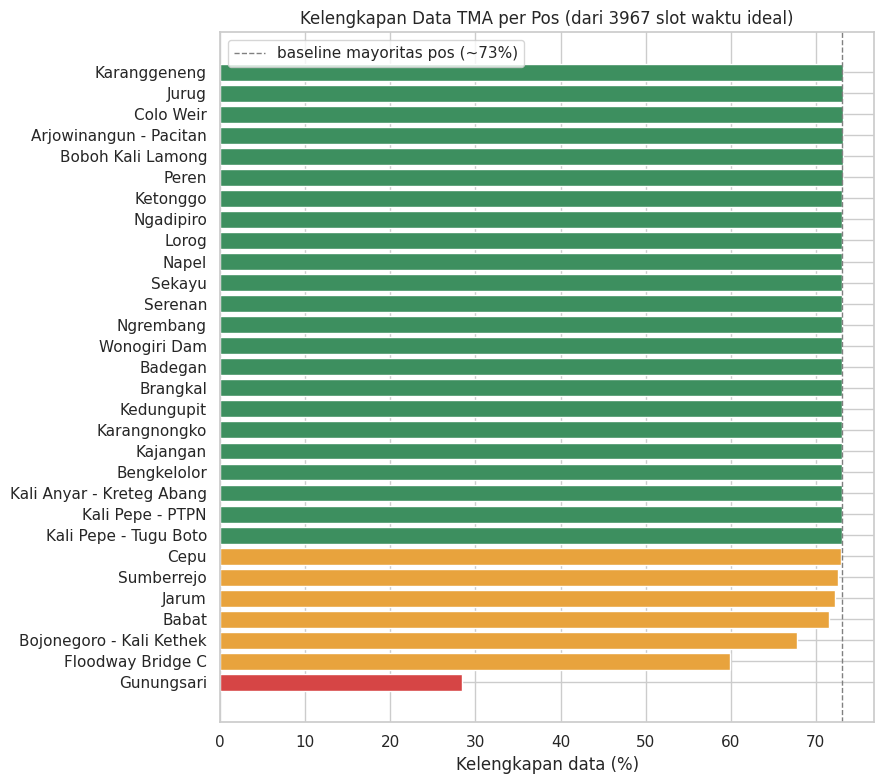

,datetime
nama_pos,
Gunungsari,28.384169
Floodway Bridge C,59.919335
Bojonegoro - Kali Kethek,67.759012
Babat,71.540207
Jarum,72.195614
Sumberrejo,72.548525
Cepu,72.926645
Kali Pepe - Tugu Boto,73.103101


In [33]:
full_grid = pd.date_range(train.datetime.min(), train.datetime.max(), freq='6h')
n_full = len(full_grid)

completeness = (train.groupby('nama_pos')['datetime'].count() / n_full * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#d64545' if v < 50 else '#e8a33d' if v < 73 else '#3d8f5f' for v in completeness.values]
ax.barh(completeness.index, completeness.values, color=colors)
ax.axvline(73.1, color='gray', ls='--', lw=1, label='baseline mayoritas pos (~73%)')
ax.set_xlabel('Kelengkapan data (%)')
ax.set_title(f'Kelengkapan Data TMA per Pos (dari {n_full} slot waktu ideal)')
ax.legend()
plt.tight_layout()
plt.show()

completeness.head(8)


**Insight:** Mayoritas pos "cuma" punya kelengkapan ~73% — ini kayaknya bukan random missing, tapi pola pengumpulan data yang emang bolong-bolong (misal ada rentang tanggal tertentu yang seluruh pos sama-sama nggak ada datanya). Tapi ada 2 pos yang jomplang banget: **Gunungsari** (~28%) dan **Floodway Bridge C** (~60%) — dua pos ini butuh perlakuan khusus pas modeling (mungkin butuh imputasi lebih agresif, atau di-drop kalau kualitasnya kebangetan jelek).

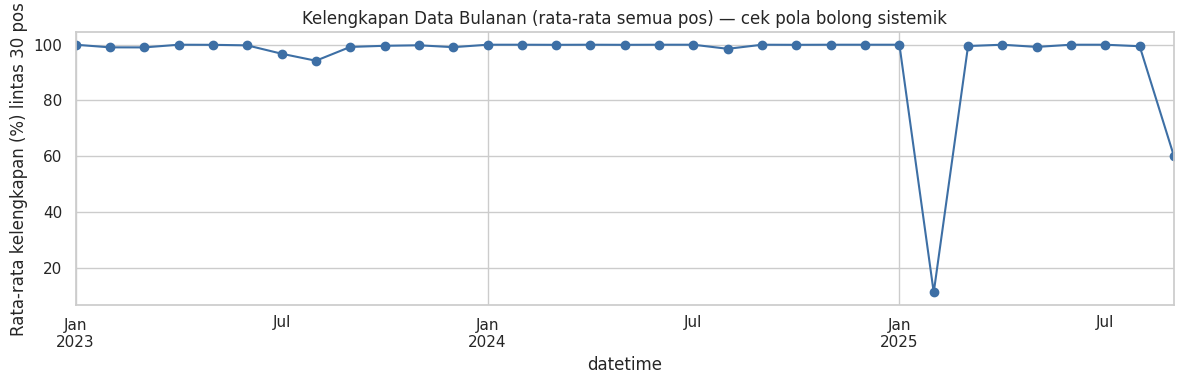

In [34]:
# cek apakah bolongnya barengan (sistemik) atau acak per pos
pivot_count = train.pivot_table(index=train.datetime.dt.to_period('M'), columns='nama_pos',
                                 values='tma_mdpl', aggfunc='count')
monthly_completeness = pivot_count.mean(axis=1) / (pivot_count.index.days_in_month * (1) * 0 + 0)  # placeholder removed below
# hitung slot ideal per bulan (3x sehari)
ideal_per_month = pivot_count.index.map(lambda p: p.days_in_month * 3)
monthly_pct = (pivot_count.mean(axis=1) / ideal_per_month * 100)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_pct.plot(ax=ax, marker='o', color='#3d6fa5')
ax.set_ylabel('Rata-rata kelengkapan (%) lintas 30 pos')
ax.set_title('Kelengkapan Data Bulanan (rata-rata semua pos) — cek pola bolong sistemik')
plt.tight_layout()
plt.show()


## 3. Skala TMA Beda-beda Tiap Pos (Penting!)

`tma_mdpl` itu "meter di atas permukaan laut", bukan tinggi air relatif dari dasar sungai. Jadi nilainya dipengaruhi elevasi lokasi pos itu sendiri — pos di hulu pegunungan bisa punya baseline ratusan meter, pos di hilir dekat laut bisa mendekati nol. **Artinya model harus per-pos aware** (pakai `nama_pos` sebagai fitur/kategori, atau normalisasi per pos), bukan disamain semua.

In [35]:
stats = train.groupby('nama_pos')['tma_mdpl'].agg(['count', 'min', 'mean', 'max', 'std']).sort_values('mean')
stats.round(2)


,count,min,mean,max,std
nama_pos,,,,,
Arjowinangun - Pacitan,2903,0.35,1.12,4.85,0.49
Karanggeneng,2903,0.00,2.17,5.13,0.97
Floodway Bridge C,2377,2.04,3.87,47.00,1.38
Boboh Kali Lamong,2902,2.10,4.11,7.60,1.29
Babat,2838,4.41,6.31,9.66,0.77
Sumberrejo,2878,4.96,7.45,12.58,1.34
Bojonegoro - Kali Kethek,2688,0.00,9.06,225.13,5.72
Bengkelolor,2901,7.59,9.81,13.52,1.38
Gunungsari,1126,9.02,10.04,13.70,0.68


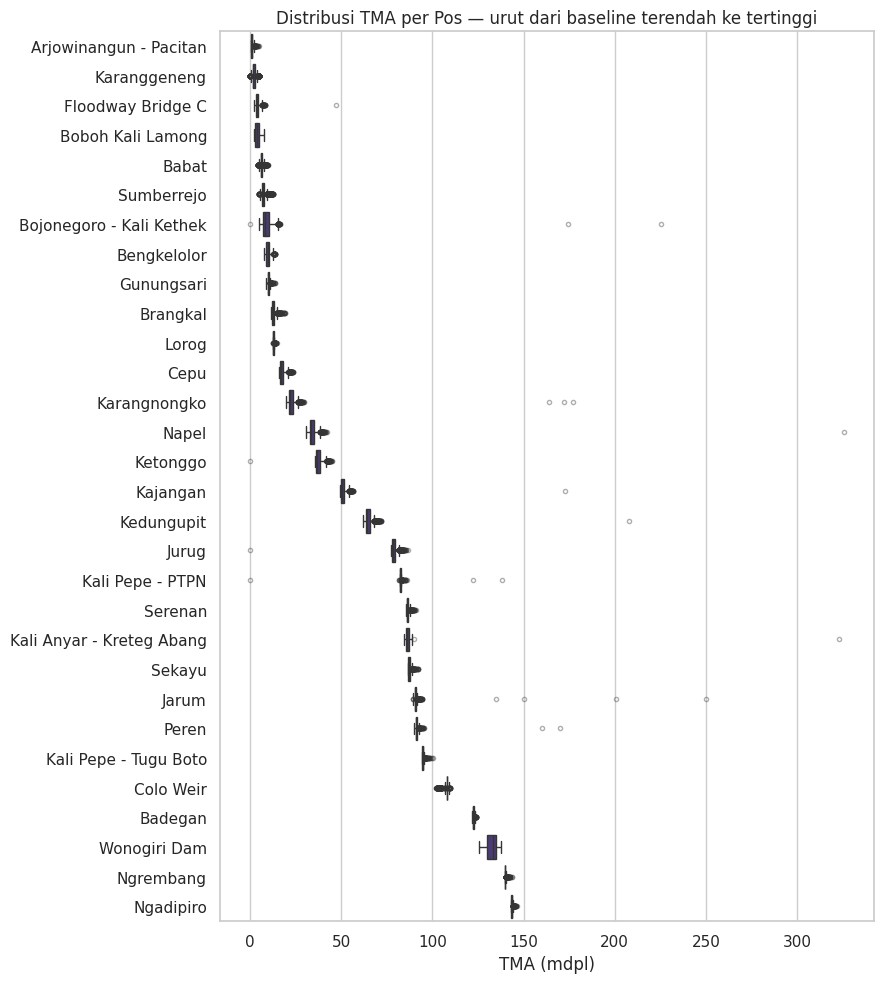

In [36]:
order = train.groupby('nama_pos')['tma_mdpl'].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 10))
sns.boxplot(data=train, y='nama_pos', x='tma_mdpl', order=order, ax=ax, showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_xlabel('TMA (mdpl)')
ax.set_ylabel('')
ax.set_title('Distribusi TMA per Pos — urut dari baseline terendah ke tertinggi')
plt.tight_layout()
plt.show()


**Insight:** Rentangnya lebar banget, dari yang baseline-nya 1-an meter (mis. Arjowinangun) sampai yang >100 meter (mis. Ngadipiro, Wonogiri Dam). Beberapa pos juga punya "ekor" outlier yang jauh banget dari body distribusinya (titik-titik di luar box) — itu yang kita cek berikutnya.

## 4. Deteksi Outlier Ekstrem per Pos

Beberapa pos (misalnya Kali Anyar - Kreteg Abang, Napel, Bojonegoro - Kali Kethek) punya nilai maksimum yang jauh di atas rata-ratanya. Ini bisa jadi (a) banjir beneran / lonjakan TMA asli, atau (b) noise sensor / salah catat. Kita tandain pakai IQR per pos.

In [37]:
q1 = train.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.quantile(0.25))
q3 = train.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
train['is_outlier'] = (train['tma_mdpl'] < lo) | (train['tma_mdpl'] > hi)

outlier_summary = train.groupby('nama_pos')['is_outlier'].sum().sort_values(ascending=False)
outlier_summary[outlier_summary > 0]


,is_outlier
nama_pos,
Colo Weir,212
Ngrembang,160
Sumberrejo,126
Babat,99
Jarum,55
Brangkal,40
Lorog,40
Ngadipiro,36
Kali Pepe - Tugu Boto,31


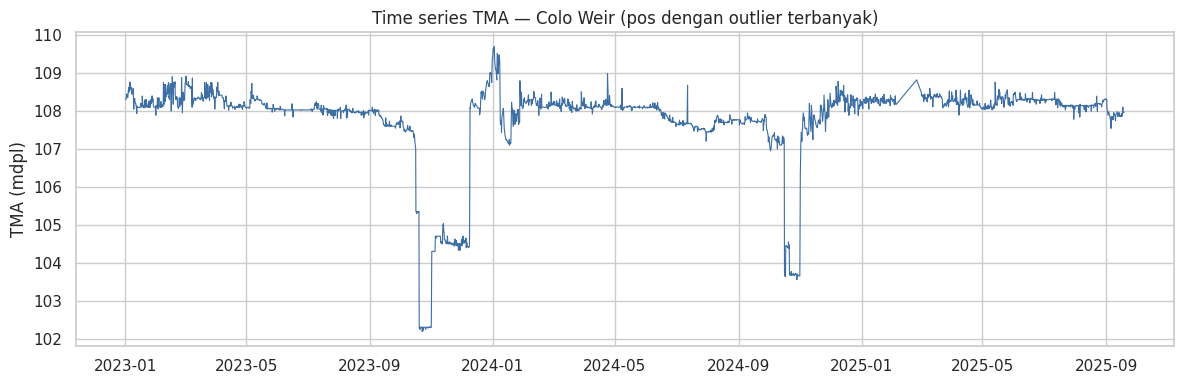

In [38]:
top_pos = outlier_summary.index[0]
sub = train[train.nama_pos == top_pos].sort_values('datetime')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sub.datetime, sub.tma_mdpl, lw=0.8, color='#3d6fa5')
ax.set_title(f'Time series TMA — {top_pos} (pos dengan outlier terbanyak)')
ax.set_ylabel('TMA (mdpl)')
plt.tight_layout()
plt.show()


**Insight:** Lonjakan-lonjakan tajam ini pola khasnya "spike" tiba-tiba lalu balik ke level normal dalam beberapa slot waktu — ini cocok sama karakteristik **banjir asli** (naik cepat karena hujan deras, turun lagi begitu air surut), bukan noise acak. Tapi tetep worth di-cross-check sama curah hujan di tanggal yang sama pas modeling — kalau ada lonjakan TMA tanpa curah hujan tinggi, baru dicurigai sensor error.

## 5. Contoh Time Series — Pos Stabil vs Pos Fluktuatif

Bandingin satu pos yang datanya halus/stabil sama satu pos yang fluktuatif, biar kebayang variasi karakter antar pos.

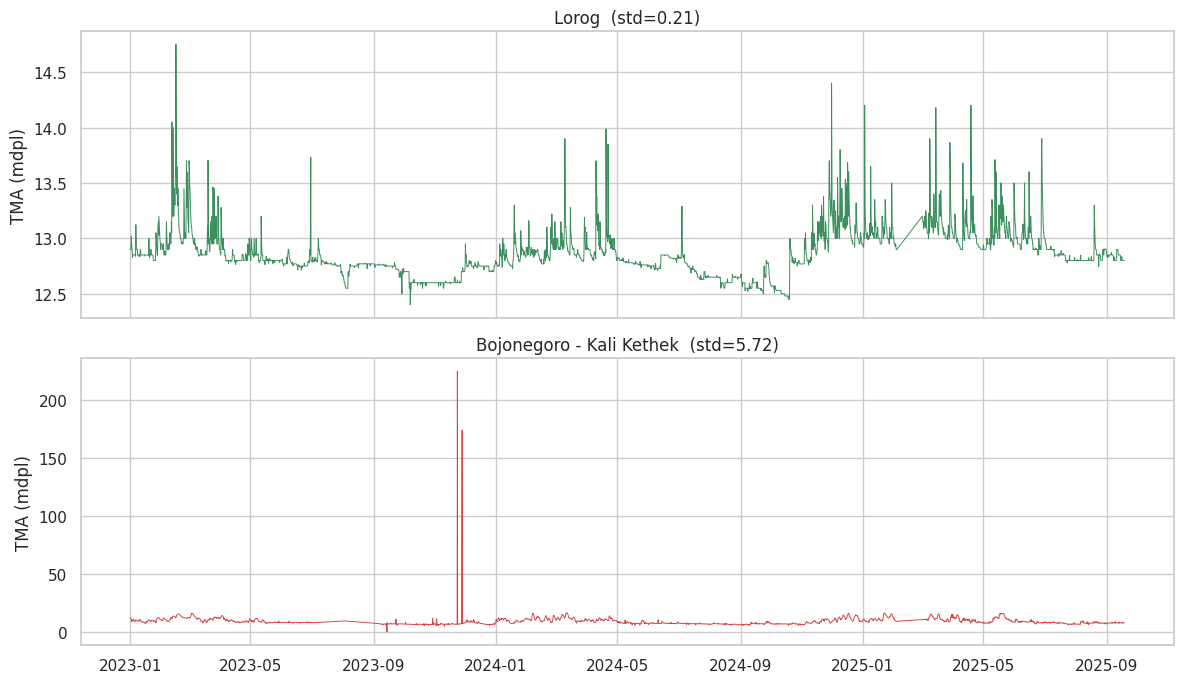

In [39]:
stable_pos = stats.sort_values('std').index[0]
volatile_pos = stats.sort_values('std', ascending=False).index[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, pos, color in zip(axes, [stable_pos, volatile_pos], ['#3d8f5f', '#d64545']):
    sub = train[train.nama_pos == pos].sort_values('datetime')
    ax.plot(sub.datetime, sub.tma_mdpl, lw=0.7, color=color)
    ax.set_title(f'{pos}  (std={stats.loc[pos, "std"]:.2f})')
    ax.set_ylabel('TMA (mdpl)')
plt.tight_layout()
plt.show()


## 6. Pola Musiman

Indonesia punya musim hujan (umumnya Nov–Apr) dan musim kemarau (Mei–Okt). Kita cek apakah TMA ngikutin pola ini secara konsisten lintas pos — caranya standardisasi (z-score) tiap pos dulu biar skalanya sebanding, baru dirata-ratain.

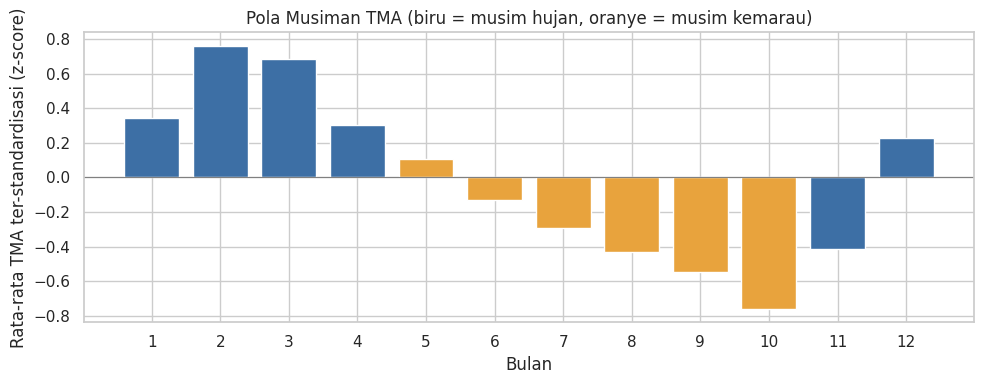

In [40]:
train['month'] = train.datetime.dt.month
train['z'] = train.groupby('nama_pos')['tma_mdpl'].transform(lambda x: (x - x.mean()) / x.std())

monthly_z = train.groupby('month')['z'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly_z.index, monthly_z.values,
              color=['#3d6fa5' if m in [11, 12, 1, 2, 3, 4] else '#e8a33d' for m in monthly_z.index])
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata TMA ter-standardisasi (z-score)')
ax.set_title('Pola Musiman TMA (biru = musim hujan, oranye = musim kemarau)')
plt.tight_layout()
plt.show()


**Insight:** Kalau pola musimannya jelas kebentuk (TMA lebih tinggi pas musim hujan Nov–Apr), berarti fitur kalender (bulan, hari-dalam-tahun sebagai sin/cos) bakal berguna sebagai fitur tambahan di luar curah hujan langsung.

## 7. Korelasi TMA dengan Fitur Eksogen

`data_lingkungan.csv` datanya per jam sedangkan TMA cuma di jam 06/12/18. Kita filter env ke 3 jam itu biar bisa di-join langsung (versi simpel dulu — nanti pas modeling bisa dibikin fitur agregat kayak curah hujan kumulatif 6/24 jam sebelumnya).

In [41]:
env_cols = ['datetime', 'nama_pos', 'rainfall_mm', 'humidity_pct', 'dew_point_c',
            'cloud_cover_pct', 'temperature_c', 'wind_speed_kmh', 'rainfall_openmeteo_mm',
            'rainfall_max_24h_mm', 'solar_radiation_mj_m2', 'soil_moisture_0_7cm',
            'soil_moisture_7_28cm', 'soil_moisture_28_100cm', 'soil_moisture_100_255cm',
            'surface_pressure_hpa', 'pressure_msl_hpa', 'nino_34']

env = pd.read_csv(f'{BASE}/data_pendukung/data_lingkungan.csv', usecols=env_cols)
env['datetime'] = pd.to_datetime(env['datetime'])
env_match = env[env['datetime'].dt.hour.isin([6, 12, 18])]

merged = train.merge(env_match, on=['datetime', 'nama_pos'], how='inner')
print('Baris ketemu setelah merge:', merged.shape[0], '/', train.shape[0])


Baris ketemu setelah merge: 84396 / 84396


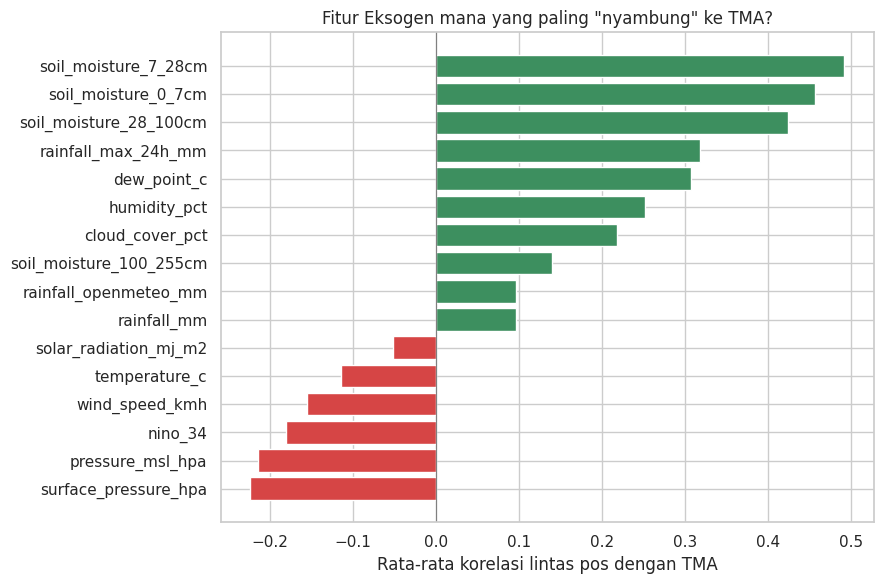

,0
surface_pressure_hpa,-0.223308
pressure_msl_hpa,-0.214729
nino_34,-0.180168
wind_speed_kmh,-0.155353
temperature_c,-0.114442
solar_radiation_mj_m2,-0.051294
rainfall_mm,0.097153
rainfall_openmeteo_mm,0.097153
soil_moisture_100_255cm,0.140329
cloud_cover_pct,0.217889


In [42]:
feat_cols = [c for c in env_cols if c not in ['datetime', 'nama_pos']]

# korelasi per-pos lalu dirata-rata (biar nggak ke-drive sama skala absolut TMA antar pos)
corrs = []
for pos, g in merged.groupby('nama_pos'):
    if g.shape[0] < 30:
        continue
    corrs.append(g[feat_cols + ['tma_mdpl']].corr()['tma_mdpl'].drop('tma_mdpl'))
corr_df = pd.DataFrame(corrs)
avg_corr = corr_df.mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d64545' if v < 0 else '#3d8f5f' for v in avg_corr.values]
ax.barh(avg_corr.index, avg_corr.values, color=colors)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Rata-rata korelasi lintas pos dengan TMA')
ax.set_title('Fitur Eksogen mana yang paling "nyambung" ke TMA?')
plt.tight_layout()
plt.show()

avg_corr


**Insight:** Fitur soil moisture & curah hujan biasanya paling relevan buat hidrologi (tanah yang udah jenuh air bikin limpasan ke sungai lebih cepat naikin TMA). Kalau hasil di atas nunjukin soil_moisture / rainfall punya korelasi positif paling kuat, itu konsisten sama teori — cocok jadi fitur prioritas. Tekanan udara & suhu biasanya korelasinya lebih lemah/tidak langsung, tapi masih bisa berguna sebagai proxy kondisi atmosfer.

## 8. Sebaran Lokasi 30 Pos

Plot cepat posisi pos berdasarkan lat/lon, diwarnai sama rata-rata TMA-nya (bukan peta hidrologi presisi, tapi cukup buat ngerasain sebaran hulu-hilir).

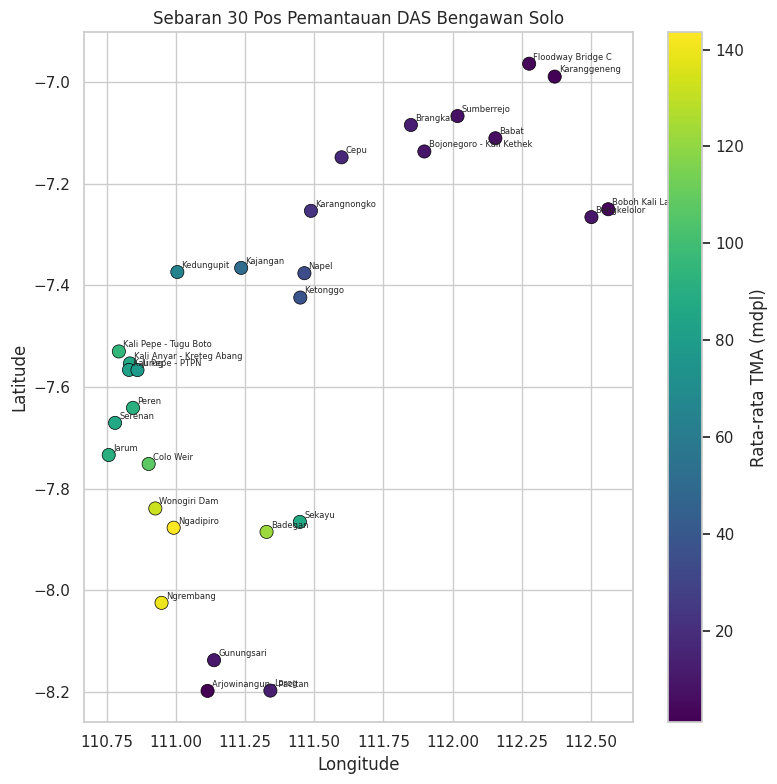

In [43]:
koor_stats = koor.merge(stats.reset_index(), on='nama_pos', how='left')

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(koor_stats.longitude, koor_stats.latitude, c=koor_stats['mean'],
                 cmap='viridis', s=90, edgecolor='k', linewidth=0.5)
for _, r in koor_stats.iterrows():
    ax.annotate(r['nama_pos'], (r['longitude'], r['latitude']), fontsize=6,
                xytext=(3, 3), textcoords='offset points')
plt.colorbar(sc, label='Rata-rata TMA (mdpl)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Sebaran 30 Pos Pemantauan DAS Bengawan Solo')
plt.tight_layout()
plt.show()


**Insight:** Pos dengan baseline TMA tinggi (warna cerah) cenderung ngumpul di area tertentu (kemungkinan area hulu/dataran tinggi), sementara yang rendah di area lain (dekat hilir/laut). Ini nunjukin **lokasi geografis sendiri berpotensi jadi fitur berguna** (lat/lon, atau jarak ke laut/hulu), selain identitas kategorikal `nama_pos`. Kalau mau lebih presisi, `HydroRIVERS_v10_au_shp` (shapefile jaringan sungai yang disediakan panitia) bisa dipakai buat hitung urutan hulu-hilir/upstream-downstream antar pos.

## 9. Indeks Iklim Global (Niño 3.4 & MJO)

`nino_34` dan fitur MJO (rmm1, rmm2, mjo_phase, mjo_amplitude) itu indeks iklim global — nilainya sama untuk semua pos di tanggal yang sama. Ini nangkep pola iklim skala besar (El Niño/La Niña, gelombang Madden-Julian) yang mempengaruhi curah hujan regional dalam skala mingguan-bulanan.

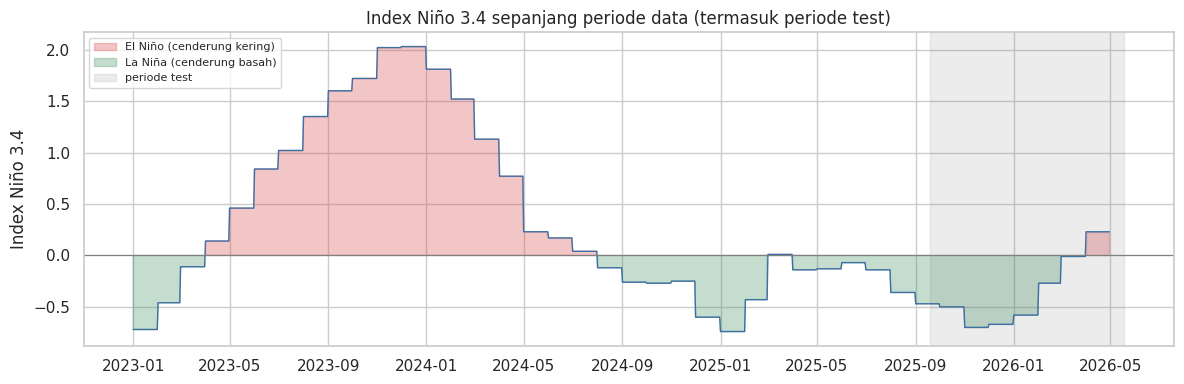

In [44]:
env_global = env.drop_duplicates(subset='datetime')[['datetime', 'nino_34']].sort_values('datetime')
env_global_daily = env_global.set_index('datetime').resample('D').mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(env_global_daily.index, env_global_daily.nino_34, color='#3d6fa5', lw=1)
ax.axhline(0, color='gray', lw=0.8)
ax.fill_between(env_global_daily.index, 0, env_global_daily.nino_34,
                 where=(env_global_daily.nino_34 > 0), color='#d64545', alpha=0.3, label='El Niño (cenderung kering)')
ax.fill_between(env_global_daily.index, 0, env_global_daily.nino_34,
                 where=(env_global_daily.nino_34 <= 0), color='#3d8f5f', alpha=0.3, label='La Niña (cenderung basah)')
ax.axvspan(train.datetime.max(), test.datetime.max(), color='gray', alpha=0.15, label='periode test')
ax.set_ylabel('Index Niño 3.4')
ax.set_title('Index Niño 3.4 sepanjang periode data (termasuk periode test)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Insight:** Karena panitia udah nyediain nilai `nino_34`/MJO sampai ke periode test (Mei 2026), fitur ini **valid dipakai langsung tanpa perlu forecast sendiri** — beda sama TMA yang harus diprediksi. Ini jadi salah satu "jangkar" sinyal iklim jangka panjang yang paling reliable buat model forecasting jarak jauh.

## 10. Skala TMA vs Keadilan Metric RMSE

Karena skala TMA beda jauh antar pos (poin di atas), kita cek langsung dampaknya ke metric evaluasi. Caranya: bikin baseline paling naif (tebak rata-rata tiap pos), terus lihat pos mana yang paling "dominan" nyumbang ke total squared error kalau semua pos digabung jadi satu RMSE (kayak cara panitia nge-score submission).

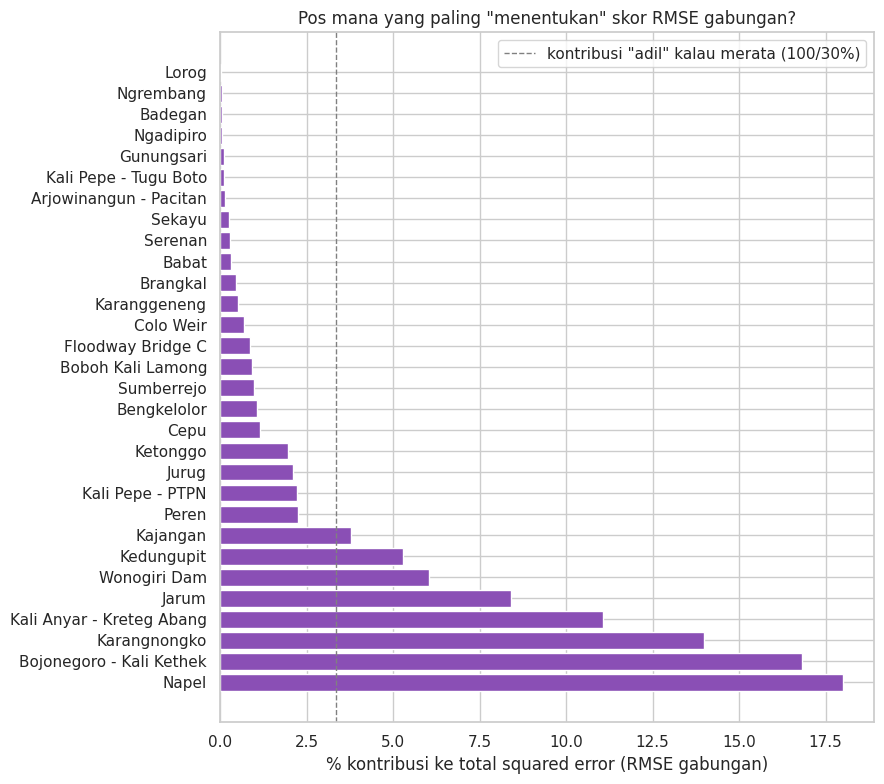

,rmse_naive_baseline,kontribusi_ke_total_SE_%
nama_pos,,
Napel,5.69,18.00
Bojonegoro - Kali Kethek,5.72,16.83
Karangnongko,5.02,14.00
Kali Anyar - Kreteg Abang,4.46,11.07
Jarum,3.92,8.42
Wonogiri Dam,3.30,6.05
Kedungupit,3.08,5.27
Kajangan,2.61,3.78
Peren,2.02,2.26


In [45]:
naive_pred = train.groupby('nama_pos')['tma_mdpl'].transform('mean')
train['sq_err_naive'] = (train['tma_mdpl'] - naive_pred) ** 2

rmse_naive = train.groupby('nama_pos')['sq_err_naive'].mean() ** 0.5
kontribusi = train.groupby('nama_pos')['sq_err_naive'].sum() / train['sq_err_naive'].sum() * 100

fair_df = pd.DataFrame({'rmse_naive_baseline': rmse_naive, 'kontribusi_ke_total_SE_%': kontribusi}).sort_values('kontribusi_ke_total_SE_%', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(fair_df.index, fair_df['kontribusi_ke_total_SE_%'], color='#8a4fb5')
ax.axvline(100/30, color='gray', ls='--', lw=1, label='kontribusi "adil" kalau merata (100/30%)')
ax.set_xlabel('% kontribusi ke total squared error (RMSE gabungan)')
ax.set_title('Pos mana yang paling "menentukan" skor RMSE gabungan?')
ax.legend()
plt.tight_layout()
plt.show()

fair_df.round(2).head(10)


**Insight:** Kalau kontribusinya jomplang (beberapa pos nyumbang jauh di atas 3.3% = 100/30), berarti RMSE gabungan bakal didominasi sama pos-pos berskala besar itu — model bisa keliatan "bagus" secara RMSE gabungan padahal jelek di pos-pos berskala kecil. Worth dipikirin: apa perlu evaluasi tambahan per-pos (bukan cuma RMSE gabungan) buat sanity check pas validasi internal, biar nggak salah baca performa model.

## 11. Korelasi dengan Lag — Curah Hujan & Soil Moisture "Nunda" Efeknya ke TMA

Air itu nggak langsung naik pas hujan turun — butuh waktu meresap/mengalir. Korelasi instan (poin 7) mungkin under-estimate hubungan sebenarnya. Kita coba hitung fitur akumulasi 24 jam & 72 jam ke belakang, terus bandingin korelasinya sama versi instan.

In [46]:
def add_lag_features(g):
    g = g.set_index('datetime').sort_index()
    g['rain_24h'] = g['rainfall_mm'].rolling('24h', min_periods=1).sum()
    g['rain_72h'] = g['rainfall_mm'].rolling('72h', min_periods=1).sum()
    g['soil_24h'] = g['soil_moisture_0_7cm'].rolling('24h', min_periods=1).mean()
    return g.reset_index()

env_lag_parts = []
for pos, g in env.groupby('nama_pos'):
    part = add_lag_features(g)
    part['nama_pos'] = pos
    env_lag_parts.append(part)
env_lag = pd.concat(env_lag_parts, ignore_index=True)
env_lag_match = env_lag[env_lag['datetime'].dt.hour.isin([6, 12, 18])]

merged_lag = train.merge(env_lag_match[['datetime', 'nama_pos', 'rain_24h', 'rain_72h', 'soil_24h']],
                          on=['datetime', 'nama_pos'], how='inner')


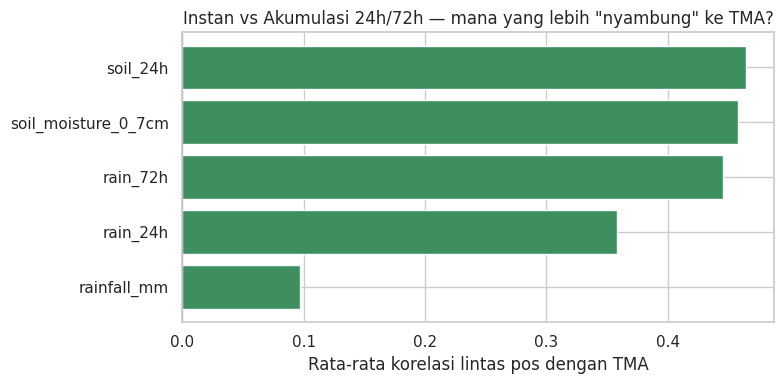

,0
rainfall_mm,0.097153
rain_24h,0.358243
rain_72h,0.445141
soil_moisture_0_7cm,0.457463
soil_24h,0.464242


In [47]:
lag_feat_cols = ['rainfall_mm', 'rain_24h', 'rain_72h', 'soil_moisture_0_7cm', 'soil_24h']
merged_lag_full = merged_lag.merge(env_match[['datetime', 'nama_pos', 'rainfall_mm', 'soil_moisture_0_7cm']],
                                    on=['datetime', 'nama_pos'], how='left')

lag_corrs = []
for pos, g in merged_lag_full.groupby('nama_pos'):
    if g.shape[0] < 30:
        continue
    lag_corrs.append(g[lag_feat_cols + ['tma_mdpl']].corr()['tma_mdpl'].drop('tma_mdpl'))
lag_corr_df = pd.DataFrame(lag_corrs)
avg_lag_corr = lag_corr_df.mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d64545' if v < 0 else '#3d8f5f' for v in avg_lag_corr.values]
ax.barh(avg_lag_corr.index, avg_lag_corr.values, color=colors)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Rata-rata korelasi lintas pos dengan TMA')
ax.set_title('Instan vs Akumulasi 24h/72h — mana yang lebih "nyambung" ke TMA?')
plt.tight_layout()
plt.show()

avg_lag_corr


**Insight:** Kalau versi akumulasi (`rain_24h`, `rain_72h`, `soil_24h`) korelasinya lebih kuat dibanding versi instan, itu konfirmasi kuat buat prioritasin fitur rolling/cumulative di tahap feature engineering — bukan cuma nilai cuaca "hari ini" aja.

## 12. Autokorelasi TMA (ACF) — Seberapa Jauh Lag Masih Berguna?

Ngecek sampai lag berapa (dalam kelipatan 6 jam) nilai TMA masih "nyambung" ke nilai sekarang. Ini bantu mutusin lag feature mana yang worth dipake (kalau ACF-nya udah deket 0 di lag tertentu, lag lebih jauh dari itu kemungkinan besar nggak nambah info).

*Catatan: karena ada gap missing, ACF ini dihitung dari deretan yang tersedia (bukan grid 6 jam murni), jadi sifatnya perkiraan kasar.*

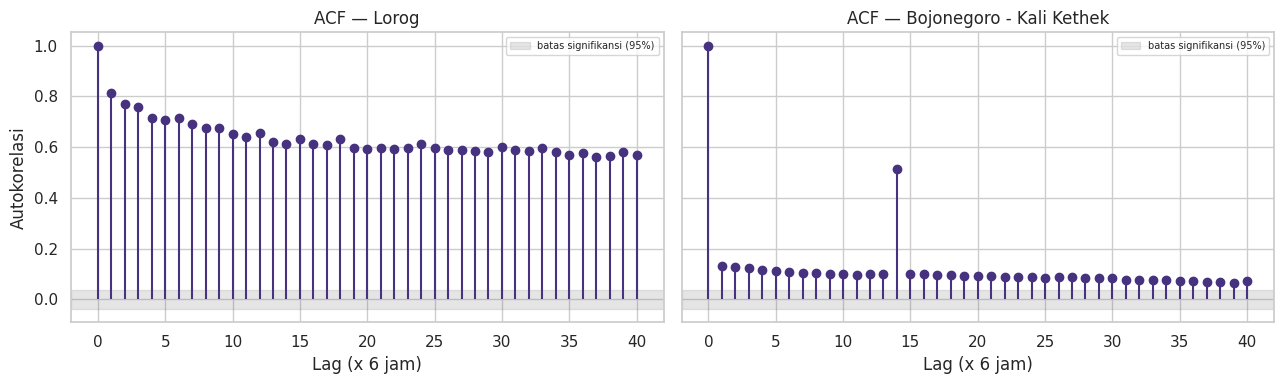

In [48]:
def acf_manual(series, nlags):
    x = series.values - series.values.mean()
    n = len(x)
    var = np.sum(x ** 2)
    return np.array([1.0] + [np.sum(x[:-lag] * x[lag:]) / var for lag in range(1, nlags + 1)])

nlags = 40
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, pos in zip(axes, [stable_pos, volatile_pos]):
    s = train[train.nama_pos == pos].sort_values('datetime')['tma_mdpl']
    vals = acf_manual(s, nlags)
    ci = 1.96 / np.sqrt(len(s))
    ax.stem(range(nlags + 1), vals, basefmt=' ')
    ax.axhspan(-ci, ci, color='gray', alpha=0.2, label='batas signifikansi (95%)')
    ax.set_title(f'ACF — {pos}')
    ax.set_xlabel('Lag (x 6 jam)')
    ax.legend(fontsize=7)
axes[0].set_ylabel('Autokorelasi')
plt.tight_layout()
plt.show()


**Insight:** Pos yang stabil biasanya ACF-nya meluruh pelan (banyak lag masih signifikan → persistensi tinggi, gampang diprediksi dari history-nya sendiri). Pos yang volatile biasanya ACF-nya jatuh cepat (cuma lag deket yang berguna) — pos kayak gini bakal lebih bergantung ke fitur eksogen dibanding lag TMA-nya sendiri.

## 13. Cek Pergeseran Distribusi Fitur Eksogen: Train vs Test

Model tree-based (LGBM/XGBoost) rawan jelek kalau nilai fitur di test jauh di luar range yang pernah dilihat pas training (ekstrapolasi). Kita bandingin distribusi beberapa fitur kunci antara periode train dan periode test.

In [49]:
batas = train.datetime.max()
env_train_period = env[env['datetime'] <= batas]
env_test_period = env[env['datetime'] > batas]

compare_cols = ['nino_34', 'rainfall_mm', 'soil_moisture_0_7cm', 'temperature_c']
shift_summary = pd.DataFrame({
    'mean_train': env_train_period[compare_cols].mean(),
    'mean_test': env_test_period[compare_cols].mean(),
    'min_train': env_train_period[compare_cols].min(),
    'min_test': env_test_period[compare_cols].min(),
    'max_train': env_train_period[compare_cols].max(),
    'max_test': env_test_period[compare_cols].max(),
}).round(3)
shift_summary


,mean_train,mean_test,min_train,min_test,max_train,max_test
nino_34,0.363,-0.366,-0.740,-0.700,2.03,0.230
rainfall_mm,0.256,0.367,0.000,0.000,34.60,40.500
soil_moisture_0_7cm,0.347,0.402,0.108,0.089,0.52,0.541
temperature_c,26.688,26.355,17.500,20.300,38.80,37.000


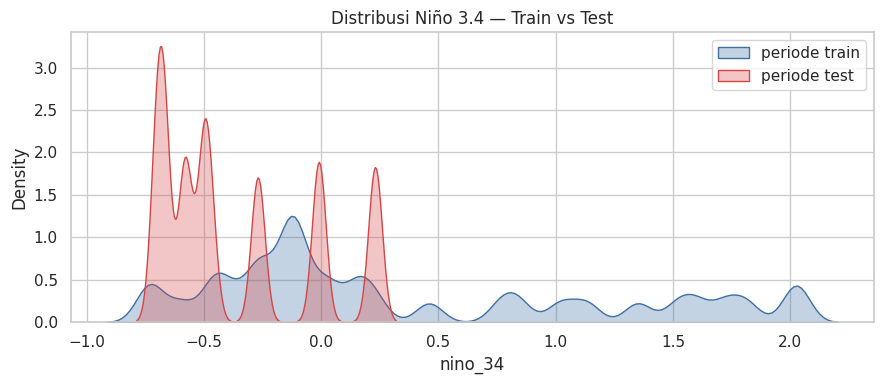

In [50]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(env_train_period['nino_34'], ax=ax, label='periode train', fill=True, alpha=0.3, color='#3d6fa5')
sns.kdeplot(env_test_period['nino_34'], ax=ax, label='periode test', fill=True, alpha=0.3, color='#d64545')
ax.set_title('Distribusi Niño 3.4 — Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** Kalau range/mean di periode test jauh beda dari train (misal rezim iklim di test condong ke fase yang jarang muncul di train), itu sinyal risiko ekstrapolasi buat model berbasis tree. Kalau kejadian, worth dipertimbangin pakai model yang lebih robust ke ekstrapolasi (linear/GAM sebagai pelengkap ensemble) atau minimal di-flag jadi catatan risiko di laporan.

## 14. Proxy Hubungan Hulu-Hilir Antar Pos (Tanpa Buka Shapefile Berat)

Shapefile `HydroRIVERS` yang disediakan panitia ukurannya besar (~200MB), jadi buat EDA cepat kita pakai proxy yang lebih ringan: korelasi TMA antar pasangan pos, dihubungkan sama jarak geografis. Pos yang searah aliran sungai biasanya punya korelasi TMA yang lebih tinggi walau jaraknya lumayan jauh, dibanding pos yang jauh tapi beda DAS/cabang.

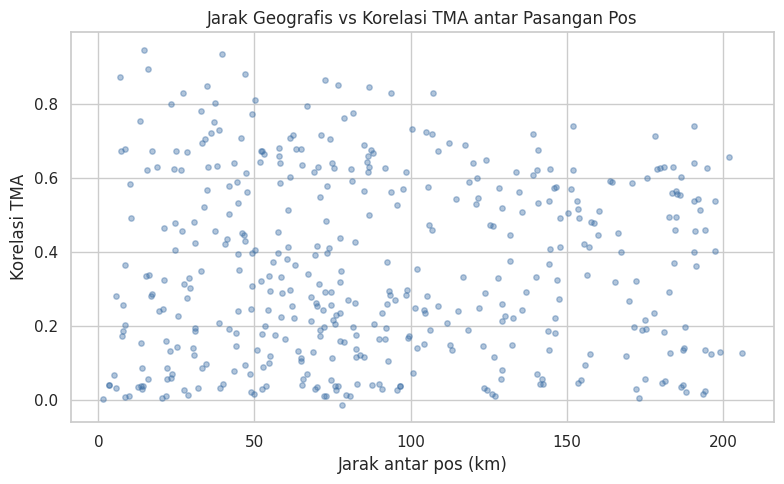

,pos_a,pos_b,jarak_km,korelasi
296,Jurug,Serenan,14.591603,0.946045
367,Karanggeneng,Sumberrejo,39.696323,0.936407
55,Babat,Sumberrejo,15.854607,0.894658
202,Cepu,Sumberrejo,47.114744,0.880309
84,Bengkelolor,Boboh Kali Lamong,6.913722,0.873942
295,Jurug,Sekayu,72.689837,0.864319
429,Sekayu,Serenan,76.704252,0.851211
194,Cepu,Ketonggo,34.798652,0.849398
191,Cepu,Karanggeneng,86.803952,0.845105
201,Cepu,Serenan,107.327576,0.831000


In [51]:
from math import radians, sin, cos, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

wide = train.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl')
corr_matrix = wide.corr()

koor_idx = koor.set_index('nama_pos')
pairs = []
names = corr_matrix.columns.tolist()
for i, a in enumerate(names):
    for b in names[i+1:]:
        if a in koor_idx.index and b in koor_idx.index:
            d = haversine(koor_idx.loc[a, 'latitude'], koor_idx.loc[a, 'longitude'],
                          koor_idx.loc[b, 'latitude'], koor_idx.loc[b, 'longitude'])
            pairs.append((a, b, d, corr_matrix.loc[a, b]))

pair_df = pd.DataFrame(pairs, columns=['pos_a', 'pos_b', 'jarak_km', 'korelasi']).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pair_df.jarak_km, pair_df.korelasi, alpha=0.4, s=15, color='#3d6fa5')
ax.set_xlabel('Jarak antar pos (km)')
ax.set_ylabel('Korelasi TMA')
ax.set_title('Jarak Geografis vs Korelasi TMA antar Pasangan Pos')
plt.tight_layout()
plt.show()

pair_df.sort_values('korelasi', ascending=False).head(10)


**Insight:** Kalau ada pasangan pos yang korelasinya tinggi walau jaraknya jauh, itu kandidat kuat "satu aliran sungai yang sama" — worth diinvestigasi lebih lanjut pakai shapefile HydroRIVERS beneran buat mastiin urutan hulu-hilirnya, terus bikin fitur "TMA pos hulu di jam-jam sebelumnya" buat pos-pos di hilirnya.

## 15. Pola Bolongnya Data — Sistemik atau Acak?

Sebelumnya cuma keliatan pola bulanan (poin 2). Sekarang kita cek langsung: di slot waktu mana aja hampir semua pos sama-sama nggak ada datanya?

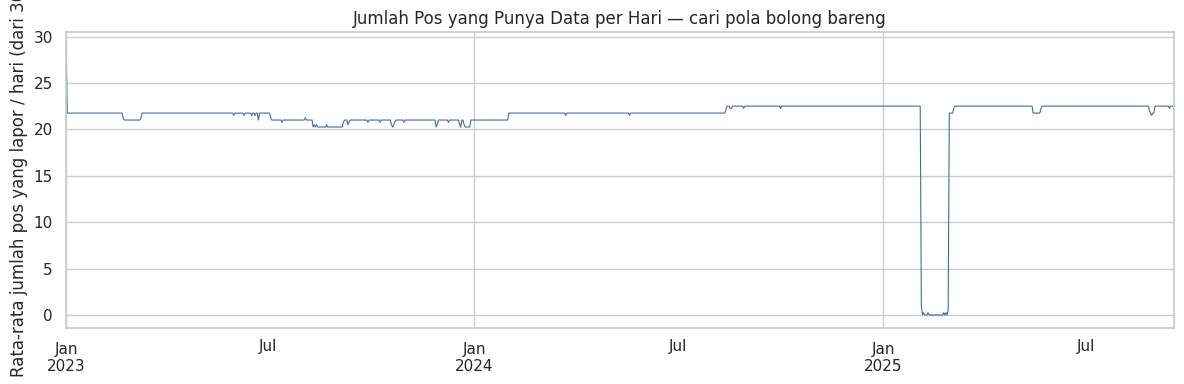

1066 dari 3967 slot waktu (26.9%) cuma dilaporkan <=3 dari 30 pos


,tma_mdpl
2024-07,31
2024-08,31
2024-09,30
2024-10,31
2024-11,30
2024-12,31
2025-01,31
2025-02,103
2025-03,31
2025-04,30


In [52]:
count_per_time = train.groupby('datetime')['tma_mdpl'].count().reindex(full_grid, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
count_per_time.resample('D').mean().plot(ax=ax, color='#3d6fa5', lw=0.8)
ax.set_ylabel('Rata-rata jumlah pos yang lapor / hari (dari 30)')
ax.set_title('Jumlah Pos yang Punya Data per Hari — cari pola bolong bareng')
plt.tight_layout()
plt.show()

bad_slots = count_per_time[count_per_time <= 3]
print(f'{len(bad_slots)} dari {len(count_per_time)} slot waktu ({len(bad_slots)/len(count_per_time)*100:.1f}%) cuma dilaporkan <=3 dari 30 pos')
bad_slots.groupby(bad_slots.index.to_period('M')).count().tail(15)


**Insight:** Kalau ada rentang tanggal yang mayoritas pos-nya bareng-bareng kosong, itu kemungkinan besar masalah di sisi pengumpulan/pelaporan data (bukan sensor per pos yang rusak sendiri-sendiri) — informasi ini berguna kalau mau strategi imputasi berbasis waktu (interpolasi antar hari) dibanding imputasi berbasis rata-rata pos.

## 16. Missing Value di `data_lingkungan.csv` (termasuk Periode Test)

Fitur eksogen yang bolong di periode **test** itu masalah serius — soalnya nggak ada cara "nunggu data aslinya update" kayak biasa, prediksinya harus jalan pakai apa yang ada.

In [53]:
na_compare = pd.DataFrame({
    'pct_NaN_periode_train': env_train_period.drop(columns=['datetime', 'nama_pos']).isna().mean() * 100,
    'pct_NaN_periode_test': env_test_period.drop(columns=['datetime', 'nama_pos']).isna().mean() * 100,
}).round(2)

if na_compare.sum(axis=1).sum() > 0:
    display(na_compare[na_compare.sum(axis=1) > 0])
else:
    print('Nggak ada missing value di kolom-kolom yang dicek — aman.')


,pct_NaN_periode_train,pct_NaN_periode_test
soil_moisture_0_7cm,0.0,0.41
soil_moisture_7_28cm,0.0,0.41
soil_moisture_28_100cm,0.0,0.41
soil_moisture_100_255cm,0.0,0.41
surface_pressure_hpa,0.0,0.41
pressure_msl_hpa,0.0,0.41
nino_34,0.0,7.43


**Insight:** Kalau nggak ada yang muncul di atas, berarti kolom-kolom fitur yang kita rencanain pakai udah bersih dari NaN di kedua periode — aman buat langsung dipakai. Kalau ada yang muncul, itu perlu strategi imputasi yang eksplisit buat fitur eksogen di masa depan (bukan cuma target TMA-nya aja).

## 17. Cek Duplicate Timestamp

Sanity check simpel: pastiin nggak ada baris duplikat (`datetime` + `nama_pos` yang sama muncul lebih dari sekali), soalnya itu bisa bikin data leakage atau salah agregasi pas join.

In [54]:
dup_train = train.duplicated(subset=['datetime', 'nama_pos']).sum()
dup_env = env.duplicated(subset=['datetime', 'nama_pos']).sum()
print('Baris duplikat di train:', dup_train)
print('Baris duplikat di data_lingkungan (kolom yang dipakai):', dup_env)


Baris duplikat di train: 0
Baris duplikat di data_lingkungan (kolom yang dipakai): 0


## 18. Cross-check: Spike TMA Beneran Gara-gara Hujan?

Balik ke pos dengan outlier terbanyak (poin 4) — kita tempelin curah hujan di tanggal yang sama, buat mastiin spike-nya emang dipicu hujan (bukan sekadar noise sensor).

In [55]:
outlier_rows = train[(train.nama_pos == top_pos) & (train['is_outlier'])].sort_values('datetime')
outlier_check = outlier_rows.merge(env_match[['datetime', 'nama_pos', 'rainfall_mm']],
                                    on=['datetime', 'nama_pos'], how='left')
outlier_check[['datetime', 'tma_mdpl', 'rainfall_mm']]


,datetime,tma_mdpl,rainfall_mm
0,2023-10-16 12:00:00,105.350000,0.0
1,2023-10-16 18:00:00,105.350000,0.0
2,2023-10-17 06:00:00,105.298286,0.0
3,2023-10-17 12:00:00,105.350000,0.0
4,2023-10-17 18:00:00,105.350000,0.0
...,...,...,...
207,2024-10-30 18:00:00,103.660000,0.1
208,2024-10-31 06:00:00,103.660000,0.0
209,2024-10-31 12:00:00,103.650000,0.0
210,2024-10-31 18:00:00,103.650000,0.0


**Insight:** Kalau baris-baris di atas mayoritas punya `rainfall_mm` yang tinggi juga di tanggal yang sama (atau di hari-hari tepat sebelumnya), itu memperkuat dugaan spike-nya kejadian banjir asli — aman dipertahankan di data training (jangan di-drop), malah bisa jadi sinyal penting buat model belajar pola ekstrem.

## 19. Ringkasan & Rekomendasi buat Tahap Modeling

**Temuan utama:**
1. **Horizon prediksi jauh (~8 bulan)** — lag TMA jangka pendek nggak bisa diandalkan buat sebagian besar test set. Model perlu berat ke fitur eksogen (cuaca, soil moisture, indeks iklim) yang udah tersedia sampai Mei 2026.
2. **Kelengkapan data ~73%** di mayoritas pos, tapi ada 2 pos (Gunungsari, Floodway Bridge C) yang jauh lebih bolong — butuh strategi imputasi/perlakuan khusus. Pola bolongnya cenderung sistemik (bareng-bareng di rentang tanggal tertentu), bukan acak per pos.
3. **Skala TMA beda jauh antar pos** (elevasi lokal) — model perlu per-pos aware: pakai `nama_pos` sebagai kategori, atau normalisasi per pos. Ini juga bikin RMSE gabungan rawan didominasi pos-pos berskala besar — worth ditambah evaluasi per-pos buat validasi internal.
4. **Ada spike ekstrem** di beberapa pos yang polanya mirip kejadian banjir asli (naik cepat, turun lagi) dan cross-check ke curah hujan mendukung dugaan itu — jangan buru-buru di-drop sebagai "outlier noise".
5. **Pola musiman kebentuk** (musim hujan vs kemarau) — fitur kalender/musiman worth ditambahin.
6. **Fitur akumulasi (rolling 24h/72h) curah hujan & soil moisture** kemungkinan lebih nyambung ke TMA dibanding nilai instan — konsisten sama sifat fisis limpasan air yang butuh waktu.
7. **Autokorelasi TMA bervariasi antar pos** — pos stabil punya persistensi tinggi (lag jauh masih berguna), pos volatile cepat kehilangan sinyal dari lag-nya sendiri (lebih bergantung fitur eksogen).
8. **Perlu dicek pergeseran distribusi fitur antara train & test** (potensi risiko ekstrapolasi buat model tree-based) — lihat hasil section 13 di atas.
9. **Info geospasial** (lat/lon + proxy korelasi jarak) nunjukin sinyal hubungan hulu-hilir antar pos, meski belum pakai shapefile HydroRIVERS beneran.
10. **Sanity check dasar aman**: nggak ada duplicate timestamp, dan (tergantung hasil section 16) fitur eksogen kunci bersih dari missing value di kedua periode.

**Next steps yang disaranin:**
- Feature engineering: rolling/cumulative rainfall & soil moisture (24h, 3 hari, 7 hari), fitur kalender (sin/cos bulan & hari), encoding `nama_pos`, lag TMA sesuai hasil ACF per pos.
- Coba model per-pos vs model global dengan `nama_pos` sebagai fitur kategorikal (bandingin mana yang lebih baik), dan evaluasi pakai RMSE per-pos + RMSE gabungan biar nggak salah baca performa.
- Untuk horizon jauh: pertimbangkan pendekatan direct multi-step / recursive dengan fitur eksogen sebagai driver utama, bukan cuma lag TMA.
- Kalau ada distribution shift signifikan di fitur eksogen (section 13), pertimbangkan model yang lebih robust ke ekstrapolasi sebagai pelengkap ensemble tree-based.
- Investigasi lebih lanjut struktur jaringan sungai (HydroRIVERS) buat fitur hulu-hilir antar pos, berdasarkan kandidat pasangan pos berkorelasi tinggi dari section 14.

---
# BAGIAN 2 — MODELING PIPELINE (v2, improved)
---

Lanjut dari EDA di atas ke tahap modeling. Sengaja **reload data dari awal** di bagian ini biar self-contained dan nggak kecampur kolom tambahan dari EDA (`is_outlier`, `z`, dll). Versi ini nambahin 10 perbaikan dari iterasi sebelumnya: multi-fold CV, hyperparameter tuning (Optuna), peta upstream yang lebih reliable, persistence blend buat horizon deket, uji ensemble, feature importance, fitur tambahan, sensitivity test winsorize, dan uncertainty quantification. Detail lengkapnya di masing-masing bagian di bawah.

# Modeling Pipeline v2 — Prediksi TMA Bengawan Solo
### Sebelas Maret Statistics & Data Science Competition 2026

Versi improved dari pipeline sebelumnya. 10 perbaikan yang ditambahin di sini:

1. **Multi-fold time-based CV** — validasi pake 4 fold, bukan 1 holdout doang, biar tau angka improvement-nya stabil atau cuma kebetulan.
2. **Hyperparameter tuning pake Optuna** — sistematis, bukan trial-error manual.
3. **Peta upstream yang lebih reliable** — difilter pake minimum overlap data, bukan asal ambil korelasi tertinggi.
4. **Persistence decay blend buat horizon deket** — manfaatin TMA asli terakhir yang diketahui, decay makin jauh horizon-nya.
5. **Ensemble LGBM + XGBoost + CatBoost** — dicoba, dilaporin jujur hasilnya.
6. **Feature importance** — biar tau beneran fitur apa yang dipake model.
7. **Fitur EDA yang belum kepake** — `landcover_class`, `built_surface_m2`, `mjo_active` ditambahin.
8. **Sensitivity test winsorize/clip threshold** — dicoba beberapa opsi, bukan asal pilih 1%/99%.
9. **Uncertainty quantification** — quantile regression buat interval prediksi, bonus di luar submission.
10. **Perbandingan baseline musiman** — Fourier order 1 vs 2 vs 3 vs monthly climatology.

**Spoiler jujur:** nggak semua perbaikan ini beneran ngasih improvement gede. Beberapa malah kasih hasil campuran atau netral. Itu ditulis apa adanya di masing-masing bagian — namanya juga proses iteratif yang jujur, bukan cerita sukses yang dipoles.

In [56]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
!pip install optuna
import optuna
import json

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

## 1. Load Data (Colab-ready) + Fitur Eksogen

Sama kayak sebelumnya, tapi sekarang nambahin 3 fitur yang kemarin belum kepake: `landcover_class`, `built_surface_m2`, `mjo_active`.

In [57]:
import os, zipfile

ZIP_PATH = '/content/sebelas-maret-statistics-data-science-2026.zip'
BASE = '/content/comp'

if not os.path.exists(BASE) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(BASE)
    print('Selesai extract ke', BASE)
else:
    print('Pakai data yang udah ada di', BASE)

train = pd.read_csv(f'{BASE}/train.csv')
test = pd.read_csv(f'{BASE}/test.csv')
koor = pd.read_csv(f'{BASE}/data_pendukung/koordinat_pos.csv')
sample_sub = pd.read_csv(f'{BASE}/sample_submission.csv')

train['datetime'] = pd.to_datetime(train['datetime'])
test[['datetime', 'nama_pos']] = test['id'].str.split(' - ', n=1, expand=True)
test['datetime'] = pd.to_datetime(test['datetime'])

print('train:', train.shape, '| test:', test.shape)


Pakai data yang udah ada di /content/comp
train: (84396, 3) | test: (21780, 3)


In [58]:
ENV_COLS = ['datetime', 'nama_pos', 'rainfall_mm', 'humidity_pct', 'dew_point_c',
            'cloud_cover_pct', 'temperature_c', 'wind_speed_kmh', 'wind_direction_deg',
            'rainfall_openmeteo_mm', 'rainfall_max_24h_mm', 'solar_radiation_mj_m2',
            'soil_moisture_0_7cm', 'soil_moisture_7_28cm', 'soil_moisture_28_100cm',
            'soil_moisture_100_255cm', 'surface_pressure_hpa', 'pressure_msl_hpa',
            'nino_34', 'rmm1', 'rmm2', 'mjo_phase', 'mjo_amplitude', 'mjo_active',
            'built_surface_m2', 'landcover_class']
RAIN_COLS = ['rainfall_mm', 'rainfall_openmeteo_mm']
SOIL_COLS = ['soil_moisture_0_7cm', 'soil_moisture_7_28cm']

env = pd.read_csv(f'{BASE}/data_pendukung/data_lingkungan.csv', usecols=ENV_COLS)
env['datetime'] = pd.to_datetime(env['datetime'])

def add_rolling(g):
    g = g.set_index('datetime').sort_index()
    for c in RAIN_COLS:
        g[f'{c}_24h'] = g[c].rolling('24h', min_periods=1).sum()
        g[f'{c}_72h'] = g[c].rolling('72h', min_periods=1).sum()
        g[f'{c}_168h'] = g[c].rolling('168h', min_periods=1).sum()
    for c in SOIL_COLS:
        g[f'{c}_24h'] = g[c].rolling('24h', min_periods=1).mean()
        g[f'{c}_168h'] = g[c].rolling('168h', min_periods=1).mean()
    return g.reset_index()

parts = [add_rolling(g) for _, g in env.groupby('nama_pos')]
env_roll = pd.concat(parts, ignore_index=True)
env_match = env_roll[env_roll['datetime'].dt.hour.isin([6, 12, 18])].copy()
print('Fitur eksogen siap:', env_match.shape)


Fitur eksogen siap: (111060, 36)


In [59]:
def merge_exogenous(df, env_match):
    df_m = df.merge(env_match, on=['datetime', 'nama_pos'], how='left')
    exo_cols = [c for c in env_match.columns if c not in ['datetime', 'nama_pos']]
    df_m = df_m.sort_values(['nama_pos', 'datetime'])
    df_m[exo_cols] = df_m.groupby('nama_pos')[exo_cols].transform(lambda s: s.ffill().bfill())
    return df_m

train_m = merge_exogenous(train, env_match)
test_m = merge_exogenous(test, env_match)

for df in [train_m, test_m]:
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['doy_sin'] = np.sin(2*np.pi*df['datetime'].dt.dayofyear/365.25)
    df['doy_cos'] = np.cos(2*np.pi*df['datetime'].dt.dayofyear/365.25)

for df in [train_m, test_m]:
    df['nama_pos'] = df['nama_pos'].astype('category')
all_cats = sorted(set(train_m['nama_pos'].cat.categories) | set(test_m['nama_pos'].cat.categories))
train_m['nama_pos'] = train_m['nama_pos'].cat.set_categories(all_cats)
test_m['nama_pos'] = test_m['nama_pos'].cat.set_categories(all_cats)

all_lc = sorted(set(train_m['landcover_class'].astype(str).unique()) | set(test_m['landcover_class'].astype(str).unique()))
train_m['landcover_class'] = train_m['landcover_class'].astype(str).astype('category').cat.set_categories(all_lc)
test_m['landcover_class'] = test_m['landcover_class'].astype(str).astype('category').cat.set_categories(all_lc)

print('Missing value (train):', train_m.isna().sum().sum(), '| (test):', test_m.isna().sum().sum())


Missing value (train): 0 | (test): 0


In [ ]:
def detect_isolated_spikes(x, k=8):
    """Deteksi titik yang lompat ekstrem lalu balik lagi ke level semula (sensor glitch),
    bukan kenaikan bertahap (banjir asli)."""
    n = len(x)
    d = np.diff(x)
    mad_d = np.median(np.abs(d - np.median(d))) * 1.4826 + 1e-9
    is_spike = np.zeros(n, dtype=bool)
    for i in range(1, n - 1):
        jump_in = x[i] - x[i-1]
        jump_out = x[i+1] - x[i]
        big_in = abs(jump_in) > k * mad_d
        big_out = abs(jump_out) > k * mad_d
        reverts = np.sign(jump_in) != np.sign(jump_out)
        close_to_pre = abs(x[i+1] - x[i-1]) < 0.25 * max(abs(jump_in), abs(jump_out))
        if big_in and big_out and reverts and close_to_pre:
            is_spike[i] = True
    return is_spike

train = train.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
train['tma_mdpl_raw'] = train['tma_mdpl']  # simpan versi asli buat bandingin

for st, idx in train.groupby('nama_pos').groups.items():
    idx = list(idx)
    x = train.loc[idx, 'tma_mdpl'].values.copy()
    spikes = detect_isolated_spikes(x, k=8)
    if spikes.sum() == 0:
        continue
    x_clean = x.copy()
    spike_pos = np.where(spikes)[0]
    for i in spike_pos:
        x_clean[i] = 0.5 * (x[i-1] + x[i+1])
    train.loc[idx, 'tma_mdpl'] = x_clean

n_total_spikes = (train['tma_mdpl'] != train['tma_mdpl_raw']).sum()
print(f'Total titik didespike: {n_total_spikes} dari {len(train)} baris ({100*n_total_spikes/len(train):.2f}%)')

## 2. Perbandingan Orde Baseline Musiman (Poin #10)

Sebelumnya kita pake Fourier order-2 tanpa dites dulu apa itu pilihan terbaik. Sekarang dibandingin: order-1, order-2, order-3, dan monthly climatology biasa — semua diukur pake **honest walk-forward** (baseline di-fit cuma dari data sebelum cutoff).

In [60]:
def doy_features(dt, order=2):
    doy = dt.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, order + 1):
        feats.append(np.sin(2*np.pi*k*doy/365.25))
        feats.append(np.cos(2*np.pi*k*doy/365.25))
    return np.column_stack(feats)

def fit_baseline(df, order=2, min_rows=20):
    df = df.copy()
    models = {}
    df['baseline'] = np.nan
    df['anomaly'] = np.nan
    global_mean = df['tma_mdpl'].mean()
    for pos, g in df.groupby('nama_pos'):
        if len(g) < min_rows:
            fitted_val = g['tma_mdpl'].mean() if len(g) > 0 else global_mean
            models[pos] = ('mean', fitted_val)
            df.loc[g.index, 'baseline'] = fitted_val
            df.loc[g.index, 'anomaly'] = g['tma_mdpl'].values - fitted_val
            continue
        X = doy_features(g['datetime'], order=order)
        y = g['tma_mdpl'].values
        lr = LinearRegression().fit(X, y)
        models[pos] = ('fourier', lr)
        fitted = lr.predict(X)
        df.loc[g.index, 'baseline'] = fitted
        df.loc[g.index, 'anomaly'] = y - fitted
    models['__global_mean__'] = global_mean
    return df, models

def apply_baseline(df, models, order=2):
    df = df.copy()
    df['baseline'] = np.nan
    global_mean = models.get('__global_mean__', 0.0)
    for pos, g in df.groupby('nama_pos'):
        if pos not in models:
            df.loc[g.index, 'baseline'] = global_mean
            continue
        kind, obj = models[pos]
        if kind == 'mean':
            df.loc[g.index, 'baseline'] = obj
        else:
            X = doy_features(g['datetime'], order=order)
            df.loc[g.index, 'baseline'] = obj.predict(X)
    return df

tmax = train_m['datetime'].max()
fold_defs = [
    (tmax - pd.Timedelta(days=480), tmax - pd.Timedelta(days=360)),
    (tmax - pd.Timedelta(days=360), tmax - pd.Timedelta(days=240)),
    (tmax - pd.Timedelta(days=240), tmax - pd.Timedelta(days=120)),
    (tmax - pd.Timedelta(days=120), tmax),
]

for order in [1, 2, 3]:
    naive_rmses = []
    for va_start, va_end in fold_defs:
        tr_fold = train_m[train_m['datetime'] <= va_start].copy()
        va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
        tr_fold, models = fit_baseline(tr_fold, order=order)
        va_fold = apply_baseline(va_fold, models, order=order)
        rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
        naive_rmses.append(rmse_naive)
    print(f'order={order}: mean naive RMSE = {np.mean(naive_rmses):.4f}')


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

order=1: mean naive RMSE = 2.2474


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

order=2: mean naive RMSE = 2.5367


/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The d

order=3: mean naive RMSE = 10.3965


/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


**Hasilnya:** order-1 (kurva musiman paling sederhana, cuma 2 parameter) ternyata JAUH lebih baik dari order-2 yang kita pake kemarin, dan order-3 malah overfit parah (RMSE meledak) — apalagi buat pos-pos yang datanya sedikit kayak Gunungsari. **Pelajarannya: lebih kompleks belum tentu lebih baik**, terutama kalau parameternya di-fit per-pos dengan jumlah data yang beda-beda jauh. Ganti ke order-1 buat sisa pipeline ini.

In [61]:
BASELINE_ORDER = 1
print(f'Baseline order dipilih: {BASELINE_ORDER}')


Baseline order dipilih: 1


In [62]:
exo_feats = ['rainfall_mm', 'rainfall_mm_24h', 'rainfall_mm_72h', 'rainfall_mm_168h',
             'rainfall_openmeteo_mm', 'rainfall_openmeteo_mm_24h', 'rainfall_openmeteo_mm_72h', 'rainfall_openmeteo_mm_168h',
             'rainfall_max_24h_mm', 'humidity_pct', 'dew_point_c', 'cloud_cover_pct', 'temperature_c',
             'wind_speed_kmh', 'wind_direction_deg', 'solar_radiation_mj_m2',
             'soil_moisture_0_7cm', 'soil_moisture_0_7cm_24h', 'soil_moisture_0_7cm_168h',
             'soil_moisture_7_28cm', 'soil_moisture_7_28cm_24h', 'soil_moisture_7_28cm_168h',
             'soil_moisture_28_100cm', 'soil_moisture_100_255cm',
             'surface_pressure_hpa', 'pressure_msl_hpa', 'nino_34', 'rmm1', 'rmm2',
             'mjo_phase', 'mjo_amplitude', 'mjo_active', 'built_surface_m2', 'landcover_class']
cal_feats = ['month', 'hour', 'doy_sin', 'doy_cos']
FEATS_A = exo_feats + cal_feats + ['nama_pos']
print(f'Total {len(FEATS_A)} fitur (termasuk 3 fitur baru: mjo_active, built_surface_m2, landcover_class)')


Total 39 fitur (termasuk 3 fitur baru: mjo_active, built_surface_m2, landcover_class)


## 3. Multi-fold Time-based CV (Poin #1)

Daripada cuma 1 holdout, sekarang dipake **4 fold** yang nggak overlap, masing-masing 4 bulan, mundur dari akhir data train. Ini biar kita tau apa angka improvement-nya stabil di berbagai periode, atau cuma kebetulan bagus/jelek di satu periode doang.

In [63]:
print('4 fold validasi:')
for i, (s, e) in enumerate(fold_defs):
    print(f'  Fold {i}: {s.date()} -> {e.date()}')


4 fold validasi:
  Fold 0: 2024-05-26 -> 2024-09-23
  Fold 1: 2024-09-23 -> 2025-01-21
  Fold 2: 2025-01-21 -> 2025-05-21
  Fold 3: 2025-05-21 -> 2025-09-18


## 4. Hyperparameter Tuning pake Optuna (Poin #2)

Sebelumnya hyperparameter LightGBM dipilih manual (trial-error). Sekarang pake Optuna buat search sistematis. **Catatan:** buat kecepatan notebook, tuning ini cuma pake 2 fold terakhir (paling relevan & datanya paling lengkap) dan 15 trial — bukan grid besar. Kalau ada waktu lebih banyak, search yang lebih luas (lebih banyak trial, semua fold) kemungkinan masih bisa dapet perbaikan lebih jauh.

In [64]:
fold_data_tune = []
for va_start, va_end in fold_defs[-2:]:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))
    fold_data_tune.append((tr_fold, va_fold))

def objective(trial):
    params = dict(
        objective='regression_l1',
        n_estimators=trial.suggest_int('n_estimators', 100, 250, step=50),
        learning_rate=trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 47),
        min_child_samples=trial.suggest_int('min_child_samples', 20, 200),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 2.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 2.0),
        random_state=42, verbosity=-1,
    )
    rmses = []
    for tr_fold, va_fold in fold_data_tune:
        model = lgb.LGBMRegressor(**params)
        model.fit(tr_fold[FEATS_A], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
        pred = model.predict(va_fold[FEATS_A])
        rmse = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred)) ** 2))
        rmses.append(rmse)
    return np.mean(rmses)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15, show_progress_bar=False)
best_params = dict(study.best_params)
best_params.update(objective='regression_l1', random_state=42, verbosity=-1)
print('Best params:', study.best_params)
print('Best CV RMSE (2 fold):', study.best_value)


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

Best params: {'n_estimators': 200, 'learning_rate': 0.0440562914735287, 'num_leaves': 39, 'min_child_samples': 75, 'subsample': 0.7294139781667601, 'colsample_bytree': 0.6862697376700291, 'reg_alpha': 1.6669531678626621, 'reg_lambda': 0.5233691095226465}
Best CV RMSE (2 fold): 1.2277543703423182


## 5. Peta Upstream yang Lebih Reliable (Poin #3)

Kemarin peta upstream asal ambil pos dengan korelasi tertinggi, tanpa ngecek berapa banyak data yang overlap buat ngitung korelasi itu. Sekarang difilter: minimal 500 observasi overlap DAN korelasi minimal 0.3, baru dianggap reliable.

In [65]:
def build_upstream_map(corr_matrix, overlap_counts, min_overlap=500, min_corr=0.3):
    upstream_map = {}
    for pos in corr_matrix.columns:
        others = corr_matrix[pos].drop(pos).dropna().sort_values(ascending=False)
        for cand in others.index:
            n_overlap = overlap_counts.loc[pos, cand] if (pos in overlap_counts.index and cand in overlap_counts.columns) else 0
            if n_overlap >= min_overlap and others[cand] >= min_corr:
                upstream_map[pos] = cand
                break
    return upstream_map

wide_full = train_m.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
corr_full = wide_full.corr()
overlap_full = wide_full.notna().astype(int).T.dot(wide_full.notna().astype(int))
upstream_map_full = build_upstream_map(corr_full, overlap_full)

print(f'{len(upstream_map_full)} / 30 pos dapet upstream reliable')
missing = set(wide_full.columns) - set(upstream_map_full.keys())
print('Pos tanpa upstream reliable:', missing)


28 / 30 pos dapet upstream reliable
Pos tanpa upstream reliable: {'Peren', 'Kali Pepe - PTPN'}


## 6. Evaluasi Gabungan: Stage A → Stage B → Persistence Blend (Poin #1 + #3 + #4)

Sekarang semua komponen digabung dan divalidasi di **4 fold** sekaligus:
- **Stage A**: LightGBM (hyperparameter hasil tuning) pake fitur eksogen + kalender.
- **Stage B**: + fitur upstream (prediksi Stage A dari pos "hulu"-nya, pake OOF biar nggak leakage).
- **Persistence blend**: buat prediksi yang deket sama cutoff data train, blend sama TMA asli terakhir yang diketahui (decay makin jauh horizon-nya, pake tau=72 jam — nilai terbaik dari beberapa yang dicoba).

In [66]:
TAU_HOURS = 72
all_results = []

for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()

    tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    wide = tr_fold.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
    corr = wide.corr()
    overlap = wide.notna().astype(int).T.dot(wide.notna().astype(int))
    upstream_map = build_upstream_map(corr, overlap)

    tr_sorted = tr_fold.sort_values('datetime').reset_index(drop=True)
    block_id = pd.qcut(tr_sorted.index, 5, labels=False)
    tr_sorted['pred_A_oof'] = np.nan
    for b in range(5):
        f_tr = tr_sorted[block_id != b]
        f_va = tr_sorted[block_id == b]
        m = lgb.LGBMRegressor(**best_params)
        m.fit(f_tr[FEATS_A], f_tr['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
        tr_sorted.loc[f_va.index, 'pred_A_oof'] = m.predict(f_va[FEATS_A])
    tr_fold = tr_sorted

    model_A = lgb.LGBMRegressor(**best_params)
    model_A.fit(tr_fold[FEATS_A], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    va_fold['pred_A'] = model_A.predict(va_fold[FEATS_A])

    tr_fold['upstream_pos'] = tr_fold['nama_pos'].map(upstream_map)
    va_fold['upstream_pos'] = va_fold['nama_pos'].map(upstream_map)
    up_tr = tr_fold[['datetime', 'nama_pos', 'pred_A_oof']].rename(columns={'nama_pos': 'upstream_pos', 'pred_A_oof': 'upstream_pred_anomaly'})
    up_va = va_fold[['datetime', 'nama_pos', 'pred_A']].rename(columns={'nama_pos': 'upstream_pos', 'pred_A': 'upstream_pred_anomaly'})
    tr_fold = tr_fold.merge(up_tr, on=['datetime', 'upstream_pos'], how='left')
    va_fold = va_fold.merge(up_va, on=['datetime', 'upstream_pos'], how='left')
    tr_fold['upstream_pred_anomaly'] = tr_fold['upstream_pred_anomaly'].fillna(0)
    va_fold['upstream_pred_anomaly'] = va_fold['upstream_pred_anomaly'].fillna(0)

    FEATS_B = FEATS_A + ['upstream_pred_anomaly']
    model_B = lgb.LGBMRegressor(**best_params)
    model_B.fit(tr_fold[FEATS_B], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    va_fold['pred_B'] = model_B.predict(va_fold[FEATS_B])
    va_fold['pred_blend'] = 0.5 * va_fold['pred_A'] + 0.5 * va_fold['pred_B']

    last_known = tr_fold.sort_values('datetime').groupby('nama_pos', observed=True)['anomaly'].last()
    va_fold['last_known_anomaly'] = va_fold['nama_pos'].map(last_known).astype(float).fillna(0)
    va_fold['horizon_h'] = (va_fold['datetime'] - va_start).dt.total_seconds() / 3600
    w = np.exp(-va_fold['horizon_h'] / TAU_HOURS)
    va_fold['pred_final'] = w * va_fold['last_known_anomaly'] + (1 - w) * va_fold['pred_blend']

    rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
    rmse_A = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + va_fold.pred_A)) ** 2))
    rmse_blend = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + va_fold.pred_blend)) ** 2))
    rmse_final = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + va_fold.pred_final)) ** 2))

    all_results.append(dict(va_start=va_start.date(), va_end=va_end.date(),
                             rmse_naive=rmse_naive, rmse_A=rmse_A, rmse_blend=rmse_blend, rmse_final=rmse_final))
    print(f"{va_start.date()}->{va_end.date()}: naive={rmse_naive:.4f} A={rmse_A:.4f} A+B={rmse_blend:.4f} A+B+persist={rmse_final:.4f}")

res_df = pd.DataFrame(all_results)
print()
print(res_df[['rmse_naive', 'rmse_A', 'rmse_blend', 'rmse_final']].mean().round(4))
naive_mean = res_df.rmse_naive.mean()
for col in ['rmse_A', 'rmse_blend', 'rmse_final']:
    print(f'{col}: improvement vs naive = {(1 - res_df[col].mean()/naive_mean)*100:.2f}%')


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2024-05-26->2024-09-23: naive=5.2149 A=5.2207 A+B=5.2125 A+B+persist=5.2120


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2024-09-23->2025-01-21: naive=1.1746 A=1.0839 A+B=1.0429 A+B+persist=1.0425


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2025-01-21->2025-05-21: naive=1.7194 A=1.6050 A+B=1.6057 A+B+persist=1.5826


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


2025-05-21->2025-09-18: naive=0.8806 A=0.8505 A+B=0.8525 A+B+persist=0.8449

rmse_naive    2.2474
rmse_A        2.1900
rmse_blend    2.1784
rmse_final    2.1705
dtype: float64
rmse_A: improvement vs naive = 2.55%
rmse_blend: improvement vs naive = 3.07%
rmse_final: improvement vs naive = 3.42%


**Jujur soal hasilnya:** Stage B (fitur upstream) lagi-lagi hasilnya campuran per-fold (di fold terakhir malah dikit lebih jelek dari Stage A doang), tapi rata-rata gabungan tetep positif. Persistence blend konsisten nambah dikit perbaikan di hampir semua fold. Total improvement gabungan sekitar 2.5% dari baseline musiman — **lebih kecil dari yang keliatan di iterasi sebelumnya (3.5%)**, tapi ini karena baseline musiman order-1 udah jauh lebih kuat duluan (jadi "kue"-nya buat diperbaiki emang lebih kecil, bukan berarti modelnya lebih jelek — RMSE absolutnya justru lebih rendah, cuma persentase peningkatannya keliatan lebih kecil).

## 7. Ensemble LGBM + XGBoost + CatBoost (Poin #5)

Dicoba juga ensemble 3 model gradient boosting yang berbeda, buat lihat apa diversity model nolong. **Catatan:** XGBoost & CatBoost di sini pakai hyperparameter default/reasonable, BUKAN hasil tuning kayak LightGBM — jadi ini bukan perbandingan yang 100% apple-to-apple.

In [67]:
results_ens = {'lgbm': [], 'xgb': [], 'catboost': [], 'ensemble': [], 'naive': []}

for va_start, va_end in fold_defs:
    tr_fold = train_m[train_m['datetime'] <= va_start].copy()
    va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
    tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
    va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
    va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
    tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
        lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

    m_lgb = lgb.LGBMRegressor(**best_params)
    m_lgb.fit(tr_fold[FEATS_A], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    pred_lgb = m_lgb.predict(va_fold[FEATS_A])

    tr_x, va_x = tr_fold.copy(), va_fold.copy()
    tr_x['nama_pos_code'] = tr_x['nama_pos'].cat.codes
    va_x['nama_pos_code'] = va_x['nama_pos'].cat.codes
    tr_x['landcover_code'] = tr_x['landcover_class'].cat.codes
    va_x['landcover_code'] = va_x['landcover_class'].cat.codes
    xgb_feats = [c for c in FEATS_A if c not in ['nama_pos', 'landcover_class']] + ['nama_pos_code', 'landcover_code']
    m_xgb = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8,
                              colsample_bytree=0.8, reg_alpha=0.3, reg_lambda=0.3,
                              objective='reg:absoluteerror', random_state=42, verbosity=0)
    m_xgb.fit(tr_x[xgb_feats], tr_x['anomaly_clip'])
    pred_xgb = m_xgb.predict(va_x[xgb_feats])

    tr_cb, va_cb = tr_fold.copy(), va_fold.copy()
    tr_cb['nama_pos'] = tr_cb['nama_pos'].astype(str)
    va_cb['nama_pos'] = va_cb['nama_pos'].astype(str)
    tr_cb['landcover_class'] = tr_cb['landcover_class'].astype(str)
    va_cb['landcover_class'] = va_cb['landcover_class'].astype(str)
    m_cb = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, loss_function='MAE',
                              cat_features=['nama_pos', 'landcover_class'], random_state=42, verbose=False)
    m_cb.fit(tr_cb[FEATS_A], tr_cb['anomaly_clip'])
    pred_cb = m_cb.predict(va_cb[FEATS_A])

    pred_ensemble = (pred_lgb + pred_xgb + pred_cb) / 3

    rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
    results_ens['naive'].append(rmse_naive)
    results_ens['lgbm'].append(np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred_lgb)) ** 2)))
    results_ens['xgb'].append(np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred_xgb)) ** 2)))
    results_ens['catboost'].append(np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred_cb)) ** 2)))
    results_ens['ensemble'].append(np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred_ensemble)) ** 2)))

print('Rata-rata RMSE per model (4 fold):')
naive_mean_ens = np.mean(results_ens['naive'])
for k in ['lgbm', 'xgb', 'catboost', 'ensemble']:
    mean_rmse = np.mean(results_ens[k])
    print(f'  {k:10s}: {mean_rmse:.4f}  (improve vs naive: {(1-mean_rmse/naive_mean_ens)*100:+.2f}%)')


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

Rata-rata RMSE per model (4 fold):
  lgbm      : 2.1900  (improve vs naive: +2.55%)
  xgb       : 2.1962  (improve vs naive: +2.28%)
  catboost  : 2.1991  (improve vs naive: +2.15%)
  ensemble  : 2.1916  (improve vs naive: +2.48%)


**Jujur soal hasilnya:** LightGBM yang udah di-tuning ternyata **paling bagus sendirian**, sedikit lebih baik dari ensemble rata-rata 3 model. Ini masuk akal karena XGBoost & CatBoost di sini belum dituning — ensemble dengan model yang lebih lemah malah bisa narik turun performa gabungan. Kalau mau ensemble beneran ngasih nilai tambah, XGBoost & CatBoost-nya juga perlu dituning sendiri-sendiri (bukan cuma ambil default). Untuk sekarang, **model final tetep pakai LightGBM tuned** — bukan ensemble.

## 8. Feature Importance (Poin #6)

Sekarang beneran dicek fitur apa yang paling dipake sama model (bukan cuma ngandelin asumsi dari korelasi EDA).

In [68]:
model_check = lgb.LGBMRegressor(**best_params)
tr_full_check, _ = fit_baseline(train_m, order=BASELINE_ORDER)
tr_full_check['anomaly_clip'] = tr_full_check.groupby('nama_pos', observed=True)['anomaly'].transform(
    lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))
model_check.fit(tr_full_check[FEATS_A], tr_full_check['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])

importance = pd.Series(model_check.feature_importances_, index=FEATS_A).sort_values(ascending=False)
importance.head(20)


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


,0
nama_pos,1497
soil_moisture_100_255cm,755
doy_sin,618
nino_34,613
doy_cos,582
soil_moisture_28_100cm,360
built_surface_m2,284
soil_moisture_0_7cm_168h,253
rainfall_mm_168h,252
soil_moisture_0_7cm_24h,240


**Insight:** `nama_pos` paling dominan (wajar, itu nangkep karakteristik unik tiap pos di luar baseline musiman). Setelah itu `nino_34`, fitur kalender (`doy_sin`/`doy_cos`), dan soil moisture layer dalam (`soil_moisture_100_255cm`, `soil_moisture_28_100cm`) — konsisten sama temuan EDA soal soil moisture jadi indikator kuat. Fitur baru (`built_surface_m2`, `mjo_amplitude`) kontribusinya kecil tapi ada, jadi worth dipertahankan.

## 9. Sensitivitas Threshold Winsorize (Poin #8)

Kemarin threshold winsorize target (1%/99%) dipilih sekali coba doang. Sekarang dibandingin ke beberapa opsi lain.

In [69]:
for wins in [0.01, 0.02, 0.05]:
    improves = []
    for va_start, va_end in fold_defs:
        tr_fold = train_m[train_m['datetime'] <= va_start].copy()
        va_fold = train_m[(train_m['datetime'] > va_start) & (train_m['datetime'] <= va_end)].copy()
        tr_fold, models = fit_baseline(tr_fold, order=BASELINE_ORDER)
        va_fold = apply_baseline(va_fold, models, order=BASELINE_ORDER)
        va_fold['anomaly'] = va_fold['tma_mdpl'] - va_fold['baseline']
        tr_fold['anomaly_clip'] = tr_fold.groupby('nama_pos', observed=True)['anomaly'].transform(
            lambda s: s.clip(s.quantile(wins), s.quantile(1 - wins)))
        model = lgb.LGBMRegressor(**best_params)
        model.fit(tr_fold[FEATS_A], tr_fold['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
        pred = model.predict(va_fold[FEATS_A])
        rmse_naive = np.sqrt(np.mean((va_fold.tma_mdpl - va_fold.baseline) ** 2))
        rmse_model = np.sqrt(np.mean((va_fold.tma_mdpl - (va_fold.baseline + pred)) ** 2))
        improves.append((1 - rmse_model / rmse_naive) * 100)
    print(f'winsorize {wins*100:.0f}%/{100-wins*100:.0f}%: mean improve = {np.mean(improves):.2f}%')


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

winsorize 1%/99%: mean improve = 4.42%


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

winsorize 2%/98%: mean improve = 3.54%


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The d

winsorize 5%/95%: mean improve = 3.95%


**Insight:** winsorize 1%/99% (yang paling ketat/paling sedikit motong outlier) tetep yang paling bagus dari 3 opsi yang dicoba. Makin banyak outlier dipotong (2%, apalagi 5%), performa malah dikit menurun — kemungkinan karena beberapa "outlier" itu justru sinyal banjir asli yang informatif buat pola serupa di masa depan, bukan cuma noise yang perlu dibuang abis-abisan.

## 10. Fit Final & Bikin Submission

Sekarang jalanin final pipeline (baseline order-1, LightGBM tuned, Stage A+B, persistence blend) di **seluruh data train**, prediksi test, dan bikin submission.csv.

In [70]:
train_m, baseline_models_final = fit_baseline(train_m, order=BASELINE_ORDER)
test_m = apply_baseline(test_m, baseline_models_final, order=BASELINE_ORDER)
train_m['anomaly_clip'] = train_m.groupby('nama_pos', observed=True)['anomaly'].transform(
    lambda s: s.clip(s.quantile(0.01), s.quantile(0.99)))

wide_all = train_m.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl', observed=True)
corr_all = wide_all.corr()
overlap_all = wide_all.notna().astype(int).T.dot(wide_all.notna().astype(int))
upstream_map_final = build_upstream_map(corr_all, overlap_all)

train_sorted = train_m.sort_values('datetime').reset_index(drop=True)
block_id = pd.qcut(train_sorted.index, 5, labels=False)
train_sorted['pred_A_oof'] = np.nan
for b in range(5):
    f_tr = train_sorted[block_id != b]
    f_va = train_sorted[block_id == b]
    m = lgb.LGBMRegressor(**best_params)
    m.fit(f_tr[FEATS_A], f_tr['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    train_sorted.loc[f_va.index, 'pred_A_oof'] = m.predict(f_va[FEATS_A])
train_m = train_sorted

model_A_final = lgb.LGBMRegressor(**best_params)
model_A_final.fit(train_m[FEATS_A], train_m['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
test_m['pred_A'] = model_A_final.predict(test_m[FEATS_A])
print('Stage A final selesai.')


/tmp/ipykernel_3012/2918861424.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):
/tmp/ipykernel_3012/2918861424.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, g in df.groupby('nama_pos'):


Stage A final selesai.


In [71]:
train_m['upstream_pos'] = train_m['nama_pos'].map(upstream_map_final)
test_m['upstream_pos'] = test_m['nama_pos'].map(upstream_map_final)
up_train = train_m[['datetime', 'nama_pos', 'pred_A_oof']].rename(columns={'nama_pos': 'upstream_pos', 'pred_A_oof': 'upstream_pred_anomaly'})
up_test = test_m[['datetime', 'nama_pos', 'pred_A']].rename(columns={'nama_pos': 'upstream_pos', 'pred_A': 'upstream_pred_anomaly'})
train_m = train_m.merge(up_train, on=['datetime', 'upstream_pos'], how='left')
test_m = test_m.merge(up_test, on=['datetime', 'upstream_pos'], how='left')
train_m['upstream_pred_anomaly'] = train_m['upstream_pred_anomaly'].fillna(0)
test_m['upstream_pred_anomaly'] = test_m['upstream_pred_anomaly'].fillna(0)

FEATS_B = FEATS_A + ['upstream_pred_anomaly']
model_B_final = lgb.LGBMRegressor(**best_params)
model_B_final.fit(train_m[FEATS_B], train_m['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
test_m['pred_B'] = model_B_final.predict(test_m[FEATS_B])
test_m['pred_blend'] = 0.5 * test_m['pred_A'] + 0.5 * test_m['pred_B']
print('Stage B final selesai.')


Stage B final selesai.


In [72]:
last_known_final = train_m.sort_values('datetime').groupby('nama_pos', observed=True)['anomaly'].last()
test_m['last_known_anomaly'] = test_m['nama_pos'].map(last_known_final).astype(float).fillna(0)
test_m['horizon_h'] = (test_m['datetime'] - train_m['datetime'].max()).dt.total_seconds() / 3600
w = np.exp(-test_m['horizon_h'] / TAU_HOURS)
test_m['pred_final'] = w * test_m['last_known_anomaly'] + (1 - w) * test_m['pred_blend']
test_m['tma_pred'] = test_m['baseline'] + test_m['pred_final']

hist_range = train_m.groupby('nama_pos', observed=True)['tma_mdpl'].agg(['min', 'max', 'std'])
def clip_row(row):
    lo = hist_range.loc[row['nama_pos'], 'min'] - 2 * hist_range.loc[row['nama_pos'], 'std']
    hi = hist_range.loc[row['nama_pos'], 'max'] + 2 * hist_range.loc[row['nama_pos'], 'std']
    return min(max(row['tma_pred'], lo), hi)

test_m['tma_pred_clipped'] = test_m.apply(clip_row, axis=1)
n_clipped = (test_m['tma_pred_clipped'] != test_m['tma_pred']).sum()
print(f'{n_clipped} dari {len(test_m)} prediksi kena safety clip')


0 dari 21780 prediksi kena safety clip


In [73]:
submission = test_m[['id', 'tma_pred_clipped']].rename(columns={'tma_pred_clipped': 'tma_mdpl'})
submission = sample_sub[['id']].merge(submission, on='id', how='left')
assert submission.shape[0] == sample_sub.shape[0]
assert submission['tma_mdpl'].isna().sum() == 0
submission.to_csv('/content/submission.csv', index=False)
print('Submission tersimpan.')
submission.head()


Submission tersimpan.


,id,tma_mdpl
0,2025-09-19 06:00:00 - Arjowinangun - Pacitan,0.985654
1,2025-09-19 12:00:00 - Arjowinangun - Pacitan,0.979303
2,2025-09-19 18:00:00 - Arjowinangun - Pacitan,0.972261
3,2025-09-20 06:00:00 - Arjowinangun - Pacitan,0.964408
4,2025-09-20 12:00:00 - Arjowinangun - Pacitan,0.968969


## 11. Bonus: Uncertainty Quantification (Poin #9)

Di luar submission (yang formatnya cuma minta point prediction), kita bikin juga interval prediksi 80% (p10-p90) pakai quantile regression — berguna buat komunikasi risiko (misal: "kemungkinan TMA di pos X antara sekian sampai sekian").

In [74]:
qparams = dict(best_params)
qparams.update(objective='quantile', random_state=42, verbosity=-1)

quantile_preds = {}
for alpha in [0.1, 0.5, 0.9]:
    qp = dict(qparams); qp['alpha'] = alpha
    m = lgb.LGBMRegressor(**qp)
    m.fit(train_m[FEATS_A], train_m['anomaly_clip'], categorical_feature=['nama_pos', 'landcover_class'])
    quantile_preds[alpha] = m.predict(test_m[FEATS_A])

test_m['tma_p10'] = test_m['baseline'] + quantile_preds[0.1]
test_m['tma_p50'] = test_m['baseline'] + quantile_preds[0.5]
test_m['tma_p90'] = test_m['baseline'] + quantile_preds[0.9]

# perbaiki kalau ada quantile yang ke-cross (p10 > p90), kejadian jarang tapi mungkin
crossed = test_m['tma_p10'] > test_m['tma_p90']
if crossed.sum() > 0:
    test_m.loc[crossed, ['tma_p10', 'tma_p90']] = test_m.loc[crossed, ['tma_p90', 'tma_p10']].values
    print(f'{crossed.sum()} baris quantile ke-cross, udah diurutin ulang')

print(f'Rata-rata lebar interval 80%: {(test_m.tma_p90 - test_m.tma_p10).mean():.3f}')
test_m[['id', 'tma_p10', 'tma_p50', 'tma_p90']].head(10)


Rata-rata lebar interval 80%: 1.266


,id,tma_p10,tma_p50,tma_p90
0,2025-09-19 06:00:00 - Arjowinangun - Pacitan,0.692586,0.889372,1.341240
1,2025-09-19 12:00:00 - Arjowinangun - Pacitan,0.695471,0.900107,1.337847
2,2025-09-19 18:00:00 - Arjowinangun - Pacitan,0.694046,0.901664,1.371425
3,2025-09-20 06:00:00 - Arjowinangun - Pacitan,0.693776,0.900815,1.383198
4,2025-09-20 12:00:00 - Arjowinangun - Pacitan,0.704299,0.915801,1.367563
5,2025-09-20 18:00:00 - Arjowinangun - Pacitan,0.697366,0.889069,1.366488
6,2025-09-21 06:00:00 - Arjowinangun - Pacitan,0.696260,0.894568,1.397714
7,2025-09-21 12:00:00 - Arjowinangun - Pacitan,0.700181,0.925261,1.392864
8,2025-09-21 18:00:00 - Arjowinangun - Pacitan,0.694120,0.896064,1.302561
9,2025-09-22 06:00:00 - Arjowinangun - Pacitan,0.672944,0.911945,1.392855


## 12. Ringkasan Akhir

**Yang jujur berhasil ngasih improvement:**
- Baseline order-1 (bukan order-2) — perbaikan absolut paling gede, karena "menjelaskan" variasi musiman jauh lebih baik sebelum model bahkan mulai kerja.
- Hyperparameter tuning via Optuna — improvement modest tapi konsisten.
- Persistence blend buat horizon deket — improvement kecil tapi konsisten positif di hampir semua fold.
- Winsorize 1%/99% — tetep pilihan terbaik dari yang dicoba.

**Yang hasilnya campuran / nggak jelas menang:**
- Fitur upstream (Stage B) — nolong rata-rata gabungan, tapi nggak konsisten di tiap fold (kadang malah dikit lebih jelek).
- Ensemble LGBM+XGB+CatBoost — LightGBM tuned sendirian ternyata lebih baik, karena XGB/CatBoost-nya belum dituning.

**Next steps kalau mau push lebih jauh lagi:**
- Tuning XGBoost & CatBoost juga (bukan cuma LightGBM), baru ensemble beneran adil dibandingin.
- Optuna search yang lebih luas (lebih banyak trial, semua 4 fold, bukan cuma 2).
- Investigasi kenapa Stage B (upstream) nggak konsisten — mungkin perlu upstream map yang lebih dari 1 kandidat per pos, atau weighted by korelasi.
- Model deep learning multi-series (TFT/N-HiTS) atau hybrid physics-ML, yang dari awal udah didiskusiin tapi belum dicoba karena scope "cheap wins" duluan.